# RAG Evaluation Logs Analysis

This notebook provides comprehensive analysis of RAG evaluation logs, comparing different models, top-k values, and golden standard datasets.

## Analysis Overview
- Load and explore evaluation log files
- Compare multiple models and configurations
- Analyze performance metrics (semantic similarity, BLEU, TF-IDF)
- Handle different golden sample datasets
- Generate visualizations and insights

## 1. Import Required Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Evaluation Logs

Load all evaluation log files from the logs directory and extract key metrics.

In [2]:
def extract_config_from_filename(filename: str) -> Dict[str, Any]:
    """Extract configuration details from filename."""
    pattern = r'answer_evaluation_results_topk(\d+)_(.+?)(?:_(\d{8}_\d{6}))?\.json'
    match = re.match(pattern, filename)
    
    if match:
        top_k = int(match.group(1))
        model = match.group(2)
        timestamp = match.group(3) if match.group(3) else "unknown"
        return {"top_k": top_k, "model": model, "timestamp": timestamp}
    return {"top_k": None, "model": filename, "timestamp": "unknown"}

def load_evaluation_logs(logs_directory: str) -> pd.DataFrame:
    """Load all evaluation log files and extract key information."""
    logs_dir = Path(logs_directory)
    log_files = list(logs_dir.glob("answer_evaluation_results_*.json"))
    
    print(f"Found {len(log_files)} log files")
    
    data = []
    for log_file in log_files:
        try:
            with open(log_file, 'r', encoding='utf-8') as f:
                log_data = json.load(f)
            
            config = extract_config_from_filename(log_file.name)
            agg_stats = log_data.get('aggregate_stats', {})
            
            record = {
                'filename': log_file.name,
                'model': config['model'],
                'top_k': config['top_k'],
                'timestamp': config['timestamp'],
                'total_questions': log_data.get('total_questions_evaluated', 0),
                'evaluation_timestamp': log_data.get('evaluation_timestamp', ''),
                'gold_standard_path': log_data.get('gold_standard_path', ''),
                
                # Semantic similarity
                'semantic_sim_mean': agg_stats.get('semantic_similarity', {}).get('mean', None),
                'semantic_sim_median': agg_stats.get('semantic_similarity', {}).get('median', None),
                'semantic_sim_std': agg_stats.get('semantic_similarity', {}).get('std', None),
                'semantic_sim_min': agg_stats.get('semantic_similarity', {}).get('min', None),
                'semantic_sim_max': agg_stats.get('semantic_similarity', {}).get('max', None),
                
                # BLEU score
                'bleu_mean': agg_stats.get('bleu_score', {}).get('mean', None),
                'bleu_median': agg_stats.get('bleu_score', {}).get('median', None),
                'bleu_std': agg_stats.get('bleu_score', {}).get('std', None),
                
                # TF-IDF similarity
                'tfidf_mean': agg_stats.get('tfidf_similarity', {}).get('mean', None),
                'tfidf_median': agg_stats.get('tfidf_similarity', {}).get('median', None),
                'tfidf_std': agg_stats.get('tfidf_similarity', {}).get('std', None),
                
                # Response time
                'response_time_mean': agg_stats.get('response_time_seconds', {}).get('mean', None),
                'response_time_median': agg_stats.get('response_time_seconds', {}).get('median', None),
                'response_time_std': agg_stats.get('response_time_seconds', {}).get('std', None),
                
                # Length ratio
                'length_ratio_mean': agg_stats.get('length_ratio', {}).get('mean', None),
                'length_ratio_median': agg_stats.get('length_ratio', {}).get('median', None),
            }
            
            data.append(record)
            
        except Exception as e:
            print(f"Error processing {log_file.name}: {e}")
    
    return pd.DataFrame(data)

# Load the data
logs_dir = Path('logs')
df_all = load_evaluation_logs(logs_dir)

print(f"\nLoaded {len(df_all)} experiments")
print(f"Models: {df_all['model'].nunique()}")
print(f"Top-K values: {sorted(df_all['top_k'].unique())}")
print(f"Date range: {df_all['evaluation_timestamp'].min()} to {df_all['evaluation_timestamp'].max()}")

Found 86 log files

Loaded 86 experiments
Models: 10
Top-K values: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
Date range: 2025-11-27T07:16:46.332575 to 2025-11-27T17:53:43.385577


## 3. Explore Dataset Structure

Display basic information about the loaded evaluation data.

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
display(df_all.head())

print("\n" + "="*80)
print("Dataset Info:")
print("="*80)
df_all.info()

print("\n" + "="*80)
print("Dataset Shape:", df_all.shape)
print("="*80)

print("\n" + "="*80)
print("Column Names:")
print("="*80)
for i, col in enumerate(df_all.columns, 1):
    print(f"{i}. {col}")

First 5 rows of the dataset:


,filename,model,top_k,timestamp,total_questions,evaluation_timestamp,gold_standard_path,semantic_sim_mean,semantic_sim_median,semantic_sim_std,...,bleu_median,bleu_std,tfidf_mean,tfidf_median,tfidf_std,response_time_mean,response_time_median,response_time_std,length_ratio_mean,length_ratio_median
0,answer_evaluation_results_topk10_InternVL3-2B-...,InternVL3-2B-Instruct-Q5_K_M,10,20251127_082203,10,2025-11-27T08:22:11.947305,data/test/sonar_gold_standard_dataset.json,0.844004,0.852745,0.062659,...,0.054698,0.042763,0.576722,0.593821,0.109948,2.391603,1.566218,1.720302,1.055981,0.501755
1,answer_evaluation_results_topk10_InternVL3_5-2...,InternVL3_5-2B-Q6_K,10,20251127_081418,10,2025-11-27T08:14:33.047666,data/test/sonar_gold_standard_dataset.json,0.835811,0.845189,0.078870,...,0.075520,0.051858,0.557002,0.577666,0.088916,31.521478,8.296175,46.330744,4.879276,1.294862
2,answer_evaluation_results_topk10_InternVL3_5-2...,InternVL3_5-2B-Q8_0,10,20251127_081848,10,2025-11-27T08:19:02.762565,data/test/sonar_gold_standard_dataset.json,0.838538,0.865418,0.098148,...,0.071575,0.097583,0.557591,0.541824,0.092500,23.639810,5.436035,40.074289,4.102996,1.441980
3,answer_evaluation_results_topk10_InternVL3_5-8...,InternVL3_5-8B-Q4_K_M,10,20251127_082113,10,2025-11-27T08:21:21.398428,data/test/sonar_gold_standard_dataset.json,0.839558,0.850490,0.081751,...,0.098571,0.044854,0.589664,0.594046,0.082441,10.947604,11.322767,4.008866,1.575505,1.531169
4,answer_evaluation_results_topk10_OpenGVLab_Int...,OpenGVLab_InternVL3_5-8B-Q6_K,10,20251127_082728,10,2025-11-27T08:27:37.586303,data/test/sonar_gold_standard_dataset.json,0.828129,0.832218,0.076467,...,0.104788,0.081996,0.584139,0.574488,0.087733,15.558952,13.909990,9.158036,1.630387,1.613982



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              86 non-null     object 
 1   model                 86 non-null     object 
 2   top_k                 86 non-null     int64  
 3   timestamp             86 non-null     object 
 4   total_questions       86 non-null     int64  
 5   evaluation_timestamp  86 non-null     object 
 6   gold_standard_path    86 non-null     object 
 7   semantic_sim_mean     86 non-null     float64
 8   semantic_sim_median   86 non-null     float64
 9   semantic_sim_std      86 non-null     float64
 10  semantic_sim_min      86 non-null     float64
 11  semantic_sim_max      86 non-null     float64
 12  bleu_mean             86 non-null     float64
 13  bleu_median           86 non-null     float64
 14  bleu_std              86 non-null     float64
 15  tfidf_mean

## 4. Analyze Different Golden Standard Datasets

Check which different golden standard datasets were used in the evaluations.

In [4]:
# Check unique golden standard datasets
unique_gold_standards = df_all['gold_standard_path'].unique()

print("="*80)
print("Golden Standard Datasets Used:")
print("="*80)
for i, path in enumerate(unique_gold_standards, 1):
    count = len(df_all[df_all['gold_standard_path'] == path])
    print(f"\n{i}. {path}")
    print(f"   Used in {count} experiments")

# Group by golden standard dataset
if len(unique_gold_standards) > 1:
    print("\n" + "="*80)
    print("Comparing Performance by Golden Standard Dataset:")
    print("="*80)
    
    gold_comparison = df_all.groupby('gold_standard_path').agg({
        'semantic_sim_mean': ['mean', 'std', 'count'],
        'bleu_mean': ['mean', 'std'],
        'tfidf_mean': ['mean', 'std'],
        'response_time_mean': ['mean', 'std']
    }).round(4)
    
    display(gold_comparison)
else:
    print("\nAll experiments use the same golden standard dataset.")

Golden Standard Datasets Used:

1. data/test/sonar_gold_standard_dataset.json
   Used in 50 experiments

2. data/test/sonar_reasoning_pro_gold_standard_dataset.json
   Used in 30 experiments

3. data/test/unrelevant_info_standard_dataset.json
   Used in 6 experiments

Comparing Performance by Golden Standard Dataset:


semantic_sim_mean          \
                                                                mean     std   
gold_standard_path                                                             
data/test/sonar_gold_standard_dataset.json                    0.8324  0.0197   
data/test/sonar_reasoning_pro_gold_standard_dat...            0.8103  0.0280   
data/test/unrelevant_info_standard_dataset.json               0.1625  0.0268   

                                                         bleu_mean          \
                                                   count      mean     std   
gold_standard_path                                                           
data/test/sonar_gold_standard_dataset.json            50    0.0844  0.0158   
data/test/sonar_reasoning_pro_gold_standard_dat...    30    0.1004  0.0187   
data/test/unrelevant_info_standard_dataset.json        6    0.0006  0.0004   

                                                   tfidf_mean          \
                                                         mean     std   
gold_standard_path                                                      
data/test/sonar_gold_standard_dataset.json             0.5575  0.0279   
data/test/sonar_reasoning_pro_gold_standard_dat...     0.5479  0.0313   
data/test/unrelevant_info_standard_dataset.json        0.0250  0.0217   

                                                   response_time_mean           
                                                                 mean      std  
gold_standard_path                                                              
data/test/sonar_gold_standard_dataset.json                    20.8318  11.2350  
data/test/sonar_reasoning_pro_gold_standard_dat...            18.9060  12.5589  
data/test/unrelevant_info_standard_dataset.json               20.0704  10.0228

## 5. Data Cleaning and Preprocessing

Get the latest run for each model-topk combination and handle any duplicates.

In [5]:
# Sort by timestamp and keep latest for each configuration
# IMPORTANT: Include gold_standard_path in groupby to preserve all datasets
df_sorted = df_all.sort_values('timestamp', ascending=False)
df_latest_all = df_sorted.groupby(['model', 'top_k', 'gold_standard_path']).first().reset_index()

print(f"Original experiments: {len(df_all)}")
print(f"Latest unique configurations (all datasets): {len(df_latest_all)}")
print(f"Unique golden datasets: {df_latest_all['gold_standard_path'].nunique()}")

# Add composite score to df_latest_all (needed for dataset comparison analysis)
df_latest_all['composite_score'] = (
    df_latest_all['semantic_sim_mean'] * 0.6 +
    df_latest_all['tfidf_mean'] * 0.2 +
    df_latest_all['bleu_mean'] * 0.2
)

# FILTER OUT irrelevant_info_standard_dataset for general analysis (sections 5-10)
# This dataset contains out-of-scope questions and would poison the results
print("\n" + "="*80)
print("FILTERING FOR GENERAL ANALYSIS (Sections 5-10)")
print("="*80)
df_latest = df_latest_all[~df_latest_all['gold_standard_path'].str.contains('irrelevant_info', case=False, na=False)].copy()

print(f"\nFiltered configurations (excluding irrelevant_info): {len(df_latest)}")
print(f"Datasets included in general analysis:")
for path in df_latest['gold_standard_path'].unique():
    count = len(df_latest[df_latest['gold_standard_path'] == path])
    print(f"  • {Path(path).stem}: {count} configs")

print(f"\n⚠️ Note: irrelevant_info_standard_dataset excluded from sections 5-10")
print(f"   It will be included in dataset comparison analysis (sections 11-15)")

# Check for missing values
print("\n" + "="*80)
print("Missing Values:")
print("="*80)
missing = df_latest.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found!")

# Composite score already calculated above for both dataframes

print("\n" + "="*80)
print("Cleaned Dataset Shape:", df_latest.shape)
print("="*80)


Original experiments: 86
Latest unique configurations (all datasets): 83
Unique golden datasets: 3

FILTERING FOR GENERAL ANALYSIS (Sections 5-10)

Filtered configurations (excluding irrelevant_info): 83
Datasets included in general analysis:
  • sonar_gold_standard_dataset: 50 configs
  • sonar_reasoning_pro_gold_standard_dataset: 30 configs
  • unrelevant_info_standard_dataset: 3 configs

⚠️ Note: irrelevant_info_standard_dataset excluded from sections 5-10
   It will be included in dataset comparison analysis (sections 11-15)

Missing Values:
No missing values found!

Cleaned Dataset Shape: (83, 24)


## 6. Statistical Analysis

Perform descriptive statistical analysis on the key metrics.

In [6]:
# Overall statistics
metrics = ['semantic_sim_mean', 'bleu_mean', 'tfidf_mean', 'response_time_mean', 'composite_score']

print("="*80)
print("OVERALL STATISTICS")
print("="*80)

stats_df = df_latest[metrics].describe().round(4)
display(stats_df)

# Statistics by model
print("\n" + "="*80)
print("STATISTICS BY MODEL")
print("="*80)

model_stats = df_latest.groupby('model')[metrics].agg(['mean', 'std', 'min', 'max']).round(4)
display(model_stats)

# Statistics by top_k
print("\n" + "="*80)
print("STATISTICS BY TOP-K VALUE")
print("="*80)

topk_stats = df_latest.groupby('top_k')[metrics].agg(['mean', 'std', 'count']).round(4)
display(topk_stats)

# Correlation analysis
print("\n" + "="*80)
print("CORRELATION MATRIX")
print("="*80)

correlation = df_latest[metrics].corr().round(3)
display(correlation)

OVERALL STATISTICS


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
count,83.0000,83.0000,83.0000,83.0000,83.0000
mean,0.7999,0.0871,0.5341,20.1101,0.6042
std,0.1282,0.0248,0.1069,11.6251,0.1012
min,0.1301,0.0002,0.0027,1.8597,0.0793
25%,0.8077,0.0746,0.5314,11.4498,0.6105
50%,0.8285,0.0881,0.5533,17.2665,0.6263
75%,0.8396,0.1009,0.5754,29.1236,0.6341
max,0.8673,0.1382,0.6157,59.1038,0.6594



STATISTICS BY MODEL


semantic_sim_mean                          \
                                               mean     std     min     max   
model                                                                         
InternVL3-2B-Instruct-Q5_K_M                 0.8248  0.0184  0.8000  0.8497   
InternVL3_5-2B-Q6_K                          0.7435  0.2222  0.1523  0.8358   
InternVL3_5-2B-Q8_0                          0.8185  0.0136  0.8047  0.8385   
InternVL3_5-8B-Q4_K_M                        0.8287  0.0215  0.7842  0.8502   
OpenGVLab_InternVL3_5-8B-Q6_K                0.7906  0.0475  0.6984  0.8516   
Qwen3-4B-Instruct-2507-Q8_0                  0.7733  0.2220  0.1823  0.8612   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            0.8399  0.0142  0.8253  0.8673   
Qwen3-8B-Q4_K_M                              0.7523  0.2334  0.1301  0.8425   
Qwen3-8B-Q5_K_M                              0.8222  0.0246  0.7865  0.8567   
Qwen3-8B-Q6_K                                0.8217  0.0195  0.7907  0.8503   

                                  bleu_mean                          \
                                       mean     std     min     max   
model                                                                 
InternVL3-2B-Instruct-Q5_K_M         0.0835  0.0155  0.0577  0.1049   
InternVL3_5-2B-Q6_K                  0.0753  0.0313  0.0009  0.1103   
InternVL3_5-2B-Q8_0                  0.0859  0.0105  0.0726  0.0992   
InternVL3_5-8B-Q4_K_M                0.1083  0.0201  0.0748  0.1382   
OpenGVLab_InternVL3_5-8B-Q6_K        0.0930  0.0192  0.0649  0.1217   
Qwen3-4B-Instruct-2507-Q8_0          0.0909  0.0367  0.0002  0.1280   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL    0.1016  0.0199  0.0743  0.1348   
Qwen3-8B-Q4_K_M                      0.0785  0.0346  0.0002  0.1153   
Qwen3-8B-Q5_K_M                      0.0740  0.0127  0.0538  0.0913   
Qwen3-8B-Q6_K                        0.0826  0.0140  0.0689  0.1128   

                                  tfidf_mean                          \
                                        mean     std     min     max   
model                                                                  
InternVL3-2B-Instruct-Q5_K_M          0.5619  0.0236  0.5236  0.5916   
InternVL3_5-2B-Q6_K                   0.4858  0.1811  0.0079  0.5757   
InternVL3_5-2B-Q8_0                   0.5441  0.0320  0.4930  0.5843   
InternVL3_5-8B-Q4_K_M                 0.5930  0.0283  0.5306  0.6157   
OpenGVLab_InternVL3_5-8B-Q6_K         0.5503  0.0319  0.5055  0.5973   
Qwen3-4B-Instruct-2507-Q8_0           0.5049  0.1890  0.0027  0.5955   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL     0.5681  0.0195  0.5399  0.5975   
Qwen3-8B-Q4_K_M                       0.4805  0.1785  0.0060  0.5593   
Qwen3-8B-Q5_K_M                       0.5252  0.0184  0.4918  0.5505   
Qwen3-8B-Q6_K                         0.5439  0.0237  0.5068  0.5875   

                                  response_time_mean                    \
                                                mean      std      min   
model                                                                    
InternVL3-2B-Instruct-Q5_K_M                  2.7211   0.6348   1.8597   
InternVL3_5-2B-Q6_K                          17.9121  10.1060  11.5904   
InternVL3_5-2B-Q8_0                          15.1960   5.8649   7.2779   
InternVL3_5-8B-Q4_K_M                        23.3125   7.5845  10.9476   
OpenGVLab_InternVL3_5-8B-Q6_K                26.9975  18.5417   9.7339   
Qwen3-4B-Instruct-2507-Q8_0                  12.5197   2.6005   9.4462   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            11.8521   2.6681   9.2840   
Qwen3-8B-Q4_K_M                              27.3193   3.2992  23.1054   
Qwen3-8B-Q5_K_M                              31.2369   3.6106  27.9321   
Qwen3-8B-Q6_K                                32.3567   3.5897  26.5461   

                                           composite_score                  \
                                       max            mean     std     min   
model                     


STATISTICS BY TOP-K VALUE


semantic_sim_mean               bleu_mean               tfidf_mean  \
                   mean     std count      mean     std count       mean   
top_k                                                                      
5                0.8178  0.0210    10    0.0755  0.0140    10     0.5466   
10               0.8423  0.0116    10    0.0893  0.0195    10     0.5681   
15               0.8205  0.0356    20    0.0969  0.0221    20     0.5593   
20               0.7406  0.2326    23    0.0790  0.0356    23     0.4835   
25               0.8174  0.0233    20    0.0915  0.0127    20     0.5438   

                    response_time_mean                composite_score          \
          std count               mean      std count            mean     std   
top_k                                                                           
5      0.0266    10            22.2820  12.8229    10          0.6151  0.0181   
10     0.0213    10            18.6311   9.5010    10          0.6369  0.0107   
15     0.0277    20            16.8481   9.9600    20          0.6236  0.0254   
20     0.1924    23            23.5997  14.1962    23          0.5569  0.1839   
25     0.0253    20            19.0128   9.9601    20          0.6175  0.0162   

             
      count  
top_k        
5        10  
10       10  
15       20  
20       23  
25       20


CORRELATION MATRIX


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
semantic_sim_mean,1.000,0.673,0.966,0.000,0.997
bleu_mean,0.673,1.000,0.736,-0.218,0.716
tfidf_mean,0.966,0.736,1.000,-0.046,0.981
response_time_mean,0.000,-0.218,-0.046,1.000,-0.020
composite_score,0.997,0.716,0.981,-0.020,1.000


## 7. Find Best Configurations

Identify the best performing model and configuration.

In [7]:
# Best by composite score
best_overall = df_latest.nlargest(5, 'composite_score')[['model', 'top_k', 'semantic_sim_mean', 
                                                           'bleu_mean', 'tfidf_mean', 
                                                           'response_time_mean', 'composite_score']]

print("="*80)
print("TOP 5 CONFIGURATIONS BY COMPOSITE SCORE")
print("="*80)
display(best_overall)

# Best by semantic similarity
best_semantic = df_latest.nlargest(5, 'semantic_sim_mean')[['model', 'top_k', 'semantic_sim_mean', 
                                                              'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 BY SEMANTIC SIMILARITY")
print("="*80)
display(best_semantic)

# Best by BLEU score
best_bleu = df_latest.nlargest(5, 'bleu_mean')[['model', 'top_k', 'bleu_mean', 'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 BY BLEU SCORE")
print("="*80)
display(best_bleu)

# Fastest models
fastest = df_latest.nsmallest(5, 'response_time_mean')[['model', 'top_k', 'composite_score', 
                                                          'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 FASTEST MODELS")
print("="*80)
display(fastest)

TOP 5 CONFIGURATIONS BY COMPOSITE SCORE


,model,top_k,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
52,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.867315,0.113277,0.581808,13.657229,0.659406
27,InternVL3_5-8B-Q4_K_M,15,0.850209,0.110181,0.613892,25.251319,0.654940
42,Qwen3-4B-Instruct-2507-Q8_0,10,0.861224,0.100936,0.586070,12.087449,0.654135
30,InternVL3_5-8B-Q4_K_M,20,0.839556,0.129575,0.615748,34.959408,0.652798
28,InternVL3_5-8B-Q4_K_M,15,0.834845,0.138227,0.615188,26.116358,0.651590



TOP 5 BY SEMANTIC SIMILARITY


,model,top_k,semantic_sim_mean,response_time_mean
52,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.867315,13.657229
42,Qwen3-4B-Instruct-2507-Q8_0,10,0.861224,12.087449
45,Qwen3-4B-Instruct-2507-Q8_0,20,0.860598,14.001995
68,Qwen3-8B-Q5_K_M,10,0.856690,27.977260
48,Qwen3-4B-Instruct-2507-Q8_0,25,0.854646,17.297667



TOP 5 BY BLEU SCORE


,model,top_k,bleu_mean,response_time_mean
28,InternVL3_5-8B-Q4_K_M,15,0.138227,26.116358
53,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.134789,9.335287
30,InternVL3_5-8B-Q4_K_M,20,0.129575,34.959408
44,Qwen3-4B-Instruct-2507-Q8_0,15,0.128022,9.446206
34,OpenGVLab_InternVL3_5-8B-Q6_K,10,0.121750,15.558952



TOP 5 FASTEST MODELS


,model,top_k,composite_score,response_time_mean
3,InternVL3-2B-Instruct-Q5_K_M,15,0.606843,1.859720
0,InternVL3-2B-Instruct-Q5_K_M,5,0.623520,2.232938
1,InternVL3-2B-Instruct-Q5_K_M,10,0.633278,2.391603
2,InternVL3-2B-Instruct-Q5_K_M,15,0.645945,2.502656
5,InternVL3-2B-Instruct-Q5_K_M,20,0.601153,2.774388


## 8. Data Visualizations

Create comprehensive visualizations to understand the data better.

### 8.1 Semantic Similarity Heatmap

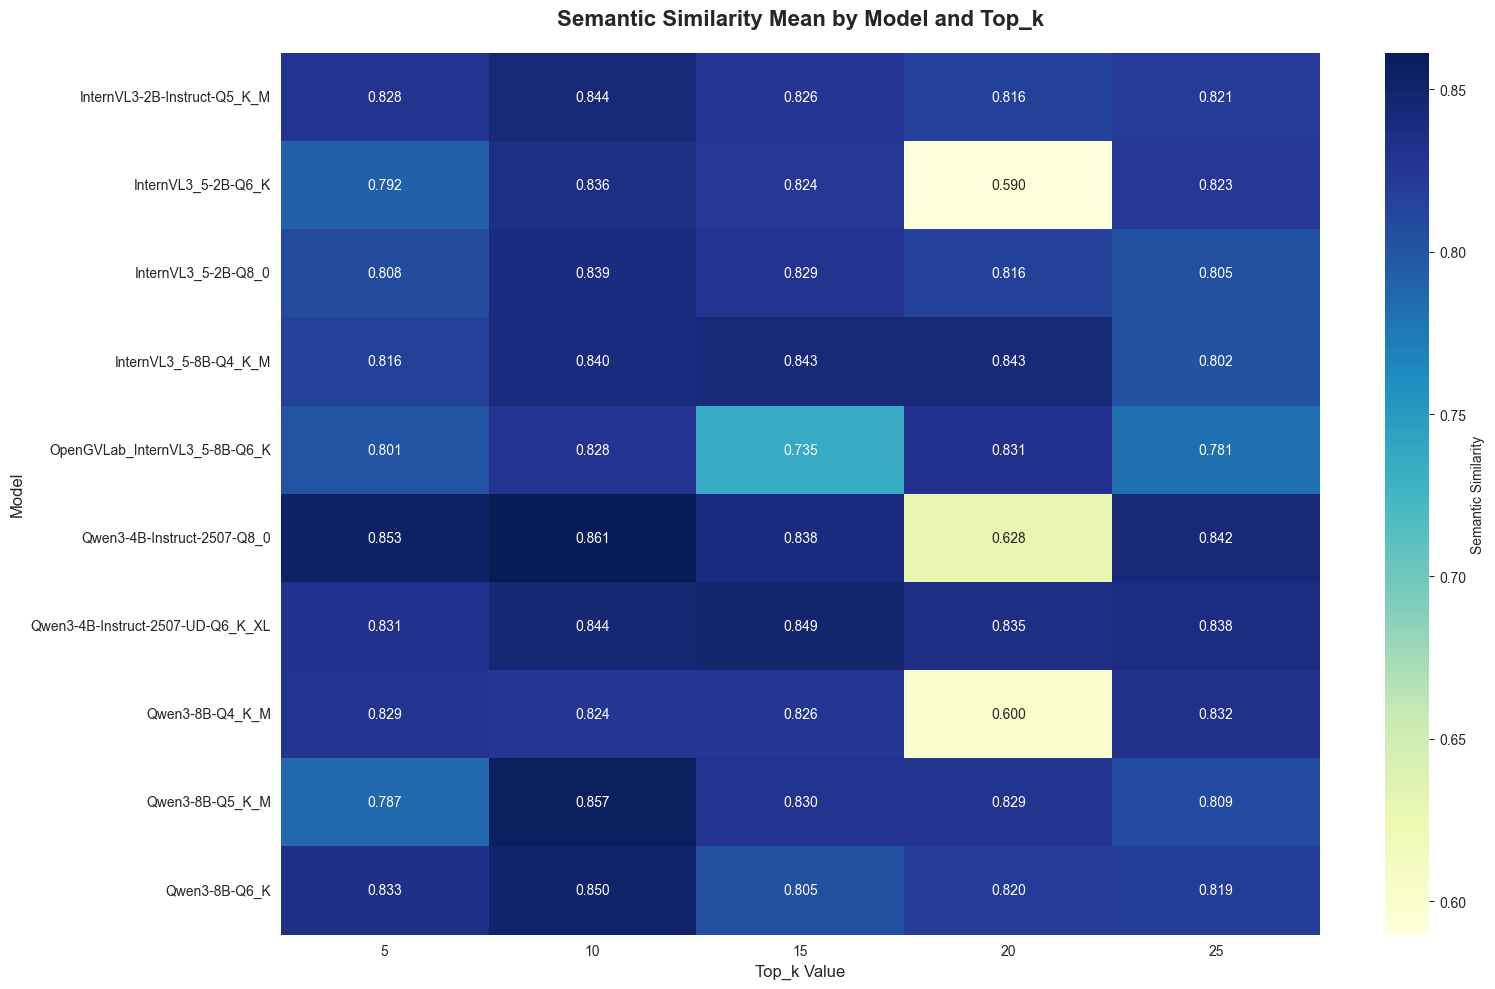

In [8]:
plt.figure(figsize=(16, 10))
pivot_sem = df_latest.pivot_table(values='semantic_sim_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Semantic Similarity'})
plt.title('Semantic Similarity Mean by Model and Top_k', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top_k Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

8.1 combined score


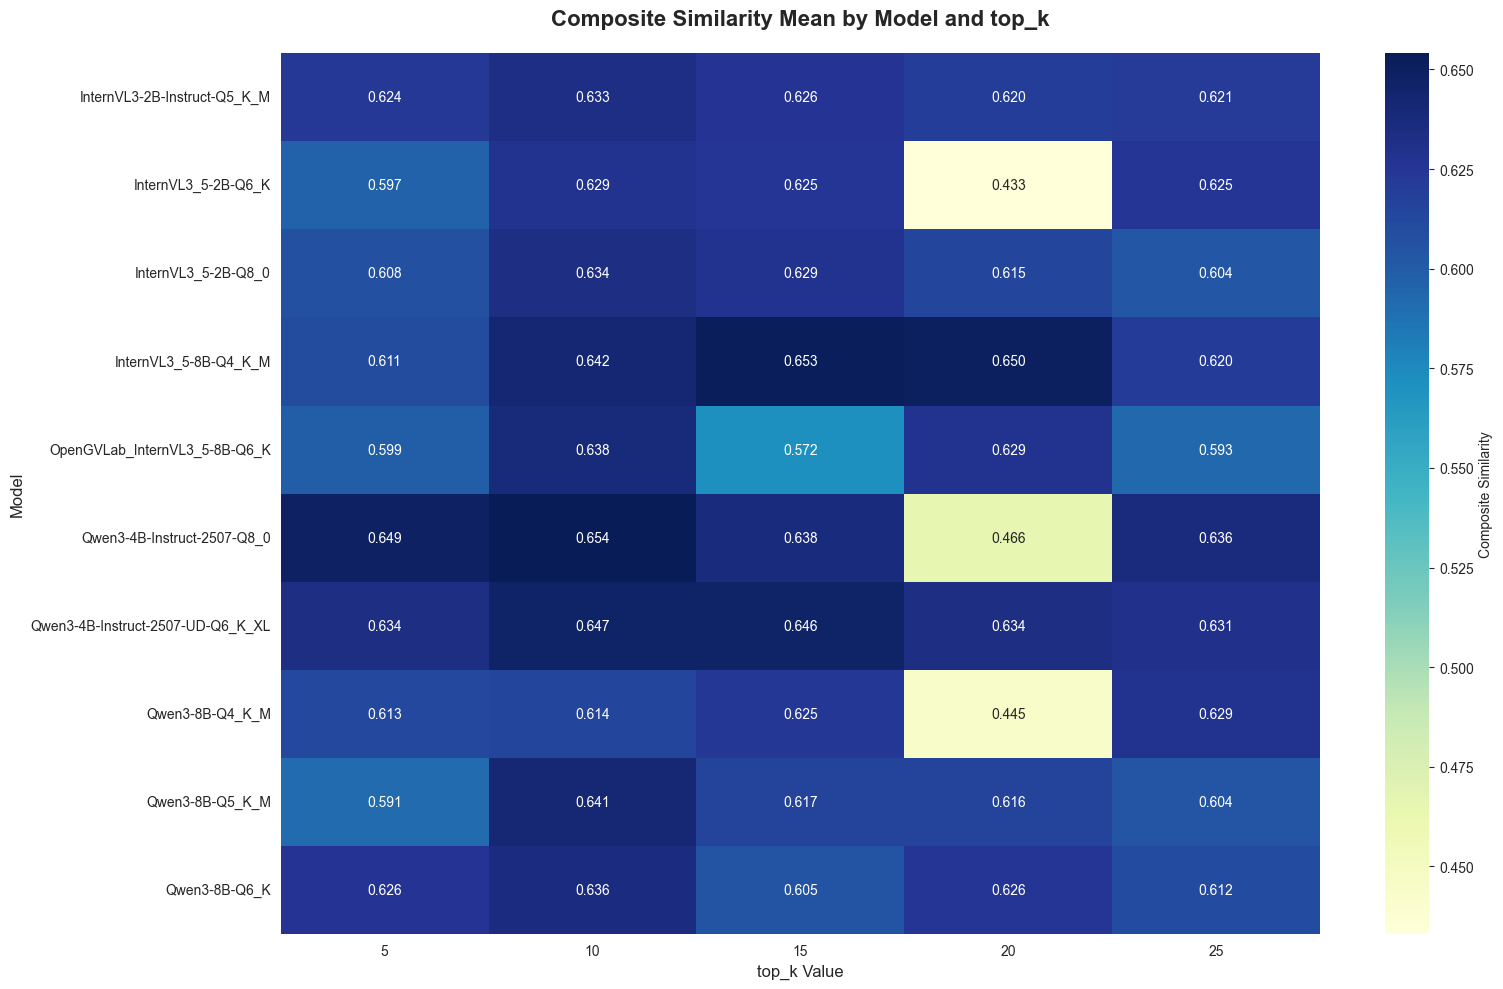

In [9]:
plt.figure(figsize=(16, 10))
pivot_sem = df_latest.pivot_table(values='composite_score', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Composite Similarity'})
plt.title('Composite Similarity Mean by Model and top_k', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('top_k Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

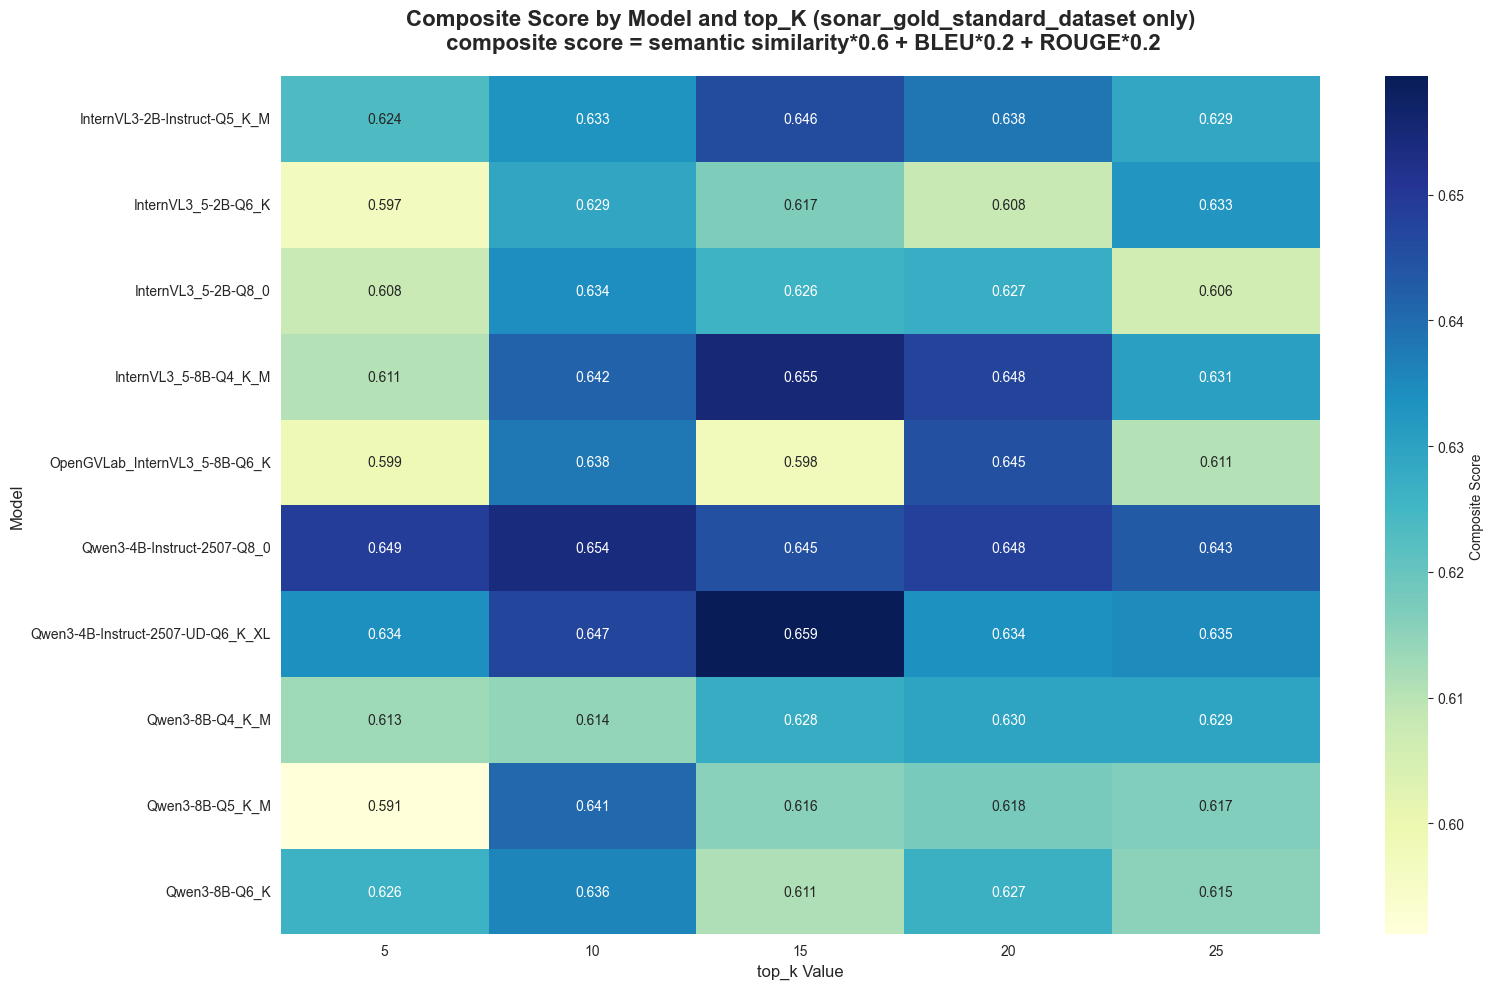


Showing data for 50 configurations from sonar_gold_standard_dataset


In [10]:
# Heatmap for specific dataset: sonar_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_gold_standard_dataset', case=False, na=False)]

plt.figure(figsize=(16, 10))
pivot_sem = df_sonar.pivot_table(values='composite_score', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Composite Score'})
plt.title('Composite Score by Model and top_K (sonar_gold_standard_dataset only)\n composite score = semantic similarity*0.6 + BLEU*0.2 + ROUGE*0.2', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('top_k Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nShowing data for {len(df_sonar)} configurations from sonar_gold_standard_dataset")

### 8.2 Response Time Heatmap

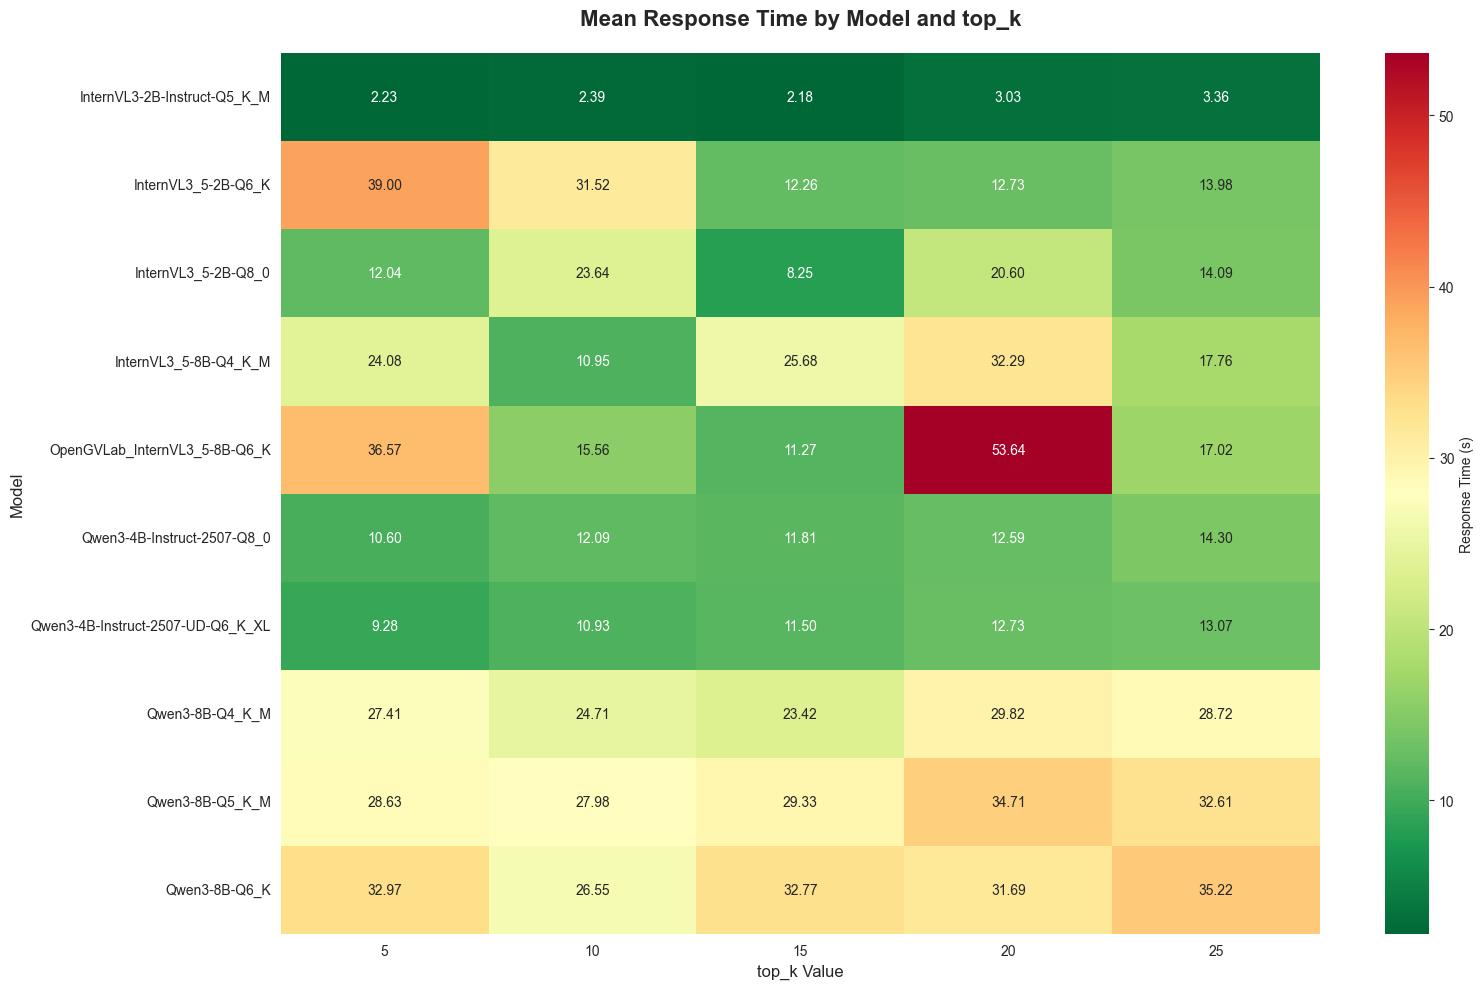

In [11]:
plt.figure(figsize=(16, 10))
pivot_time = df_latest.pivot_table(values='response_time_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Response Time (s)'})
plt.title('Mean Response Time by Model and top_k', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('top_k Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

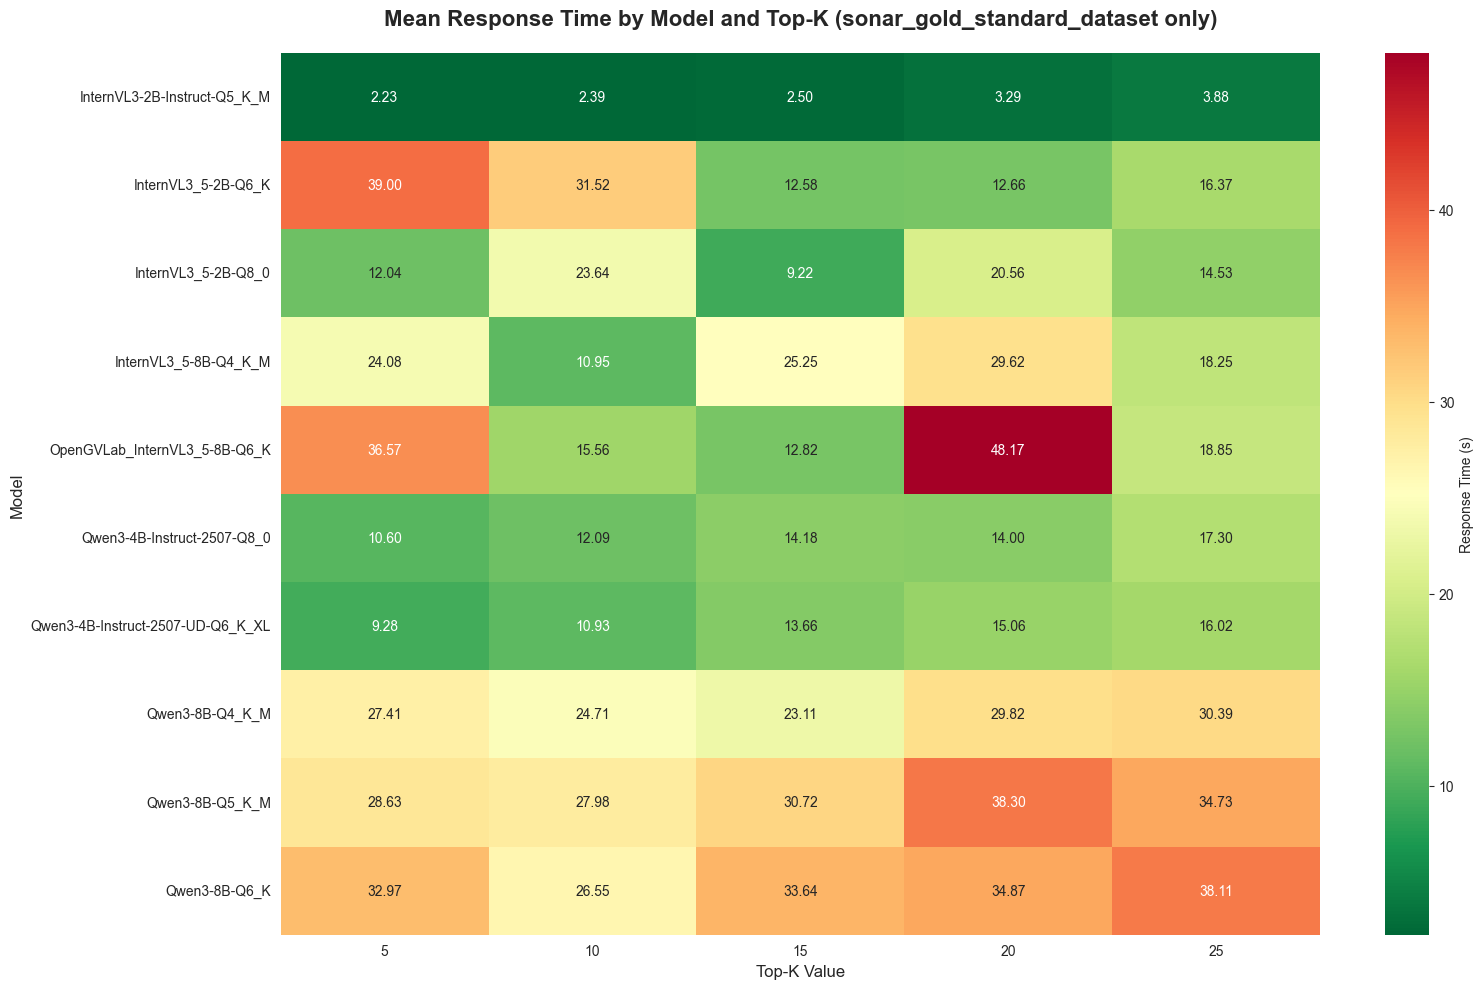


Showing response time data for 50 configurations from sonar_gold_standard_dataset


In [12]:
# Response time heatmap for sonar_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_gold_standard_dataset', case=False, na=False)]

plt.figure(figsize=(16, 10))
pivot_time = df_sonar.pivot_table(values='response_time_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Response Time (s)'})
plt.title('Mean Response Time by Model and Top-K (sonar_gold_standard_dataset only)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nShowing response time data for {len(df_sonar)} configurations from sonar_gold_standard_dataset")

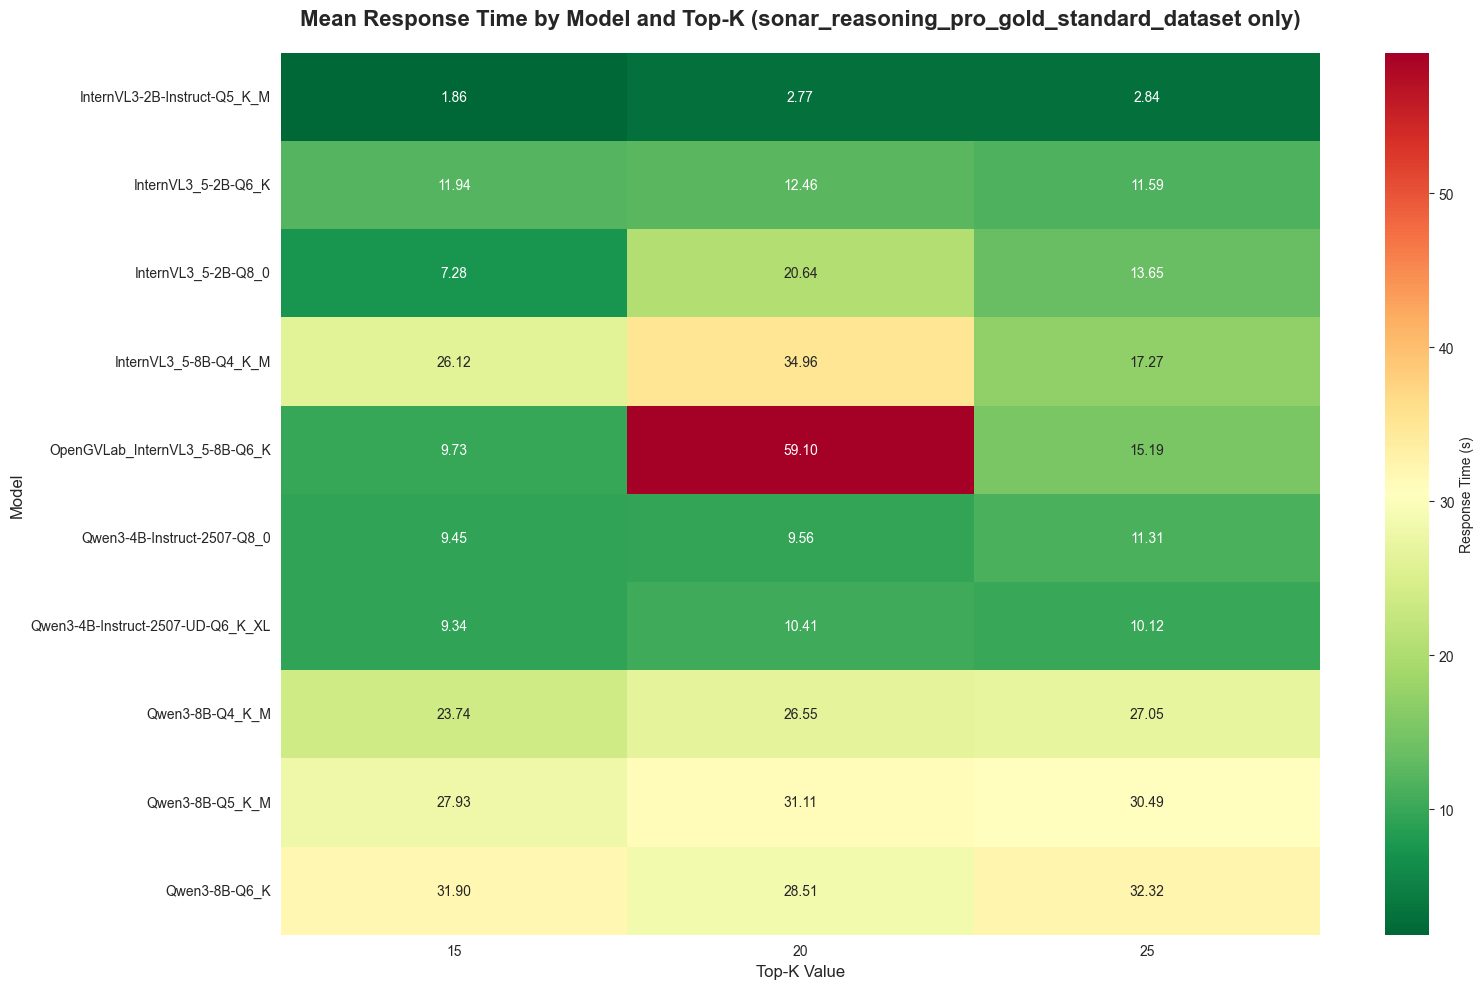


Showing response time data for 30 configurations from sonar_reasoning_pro_gold_standard_dataset


In [13]:
# Response time heatmap for sonar_reasoning_pro_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_reasoning_pro_gold_standard_dataset', case=False, na=False)]

plt.figure(figsize=(16, 10))
pivot_time = df_sonar.pivot_table(values='response_time_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Response Time (s)'})
plt.title('Mean Response Time by Model and Top-K (sonar_reasoning_pro_gold_standard_dataset only)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nShowing response time data for {len(df_sonar)} configurations from sonar_reasoning_pro_gold_standard_dataset")

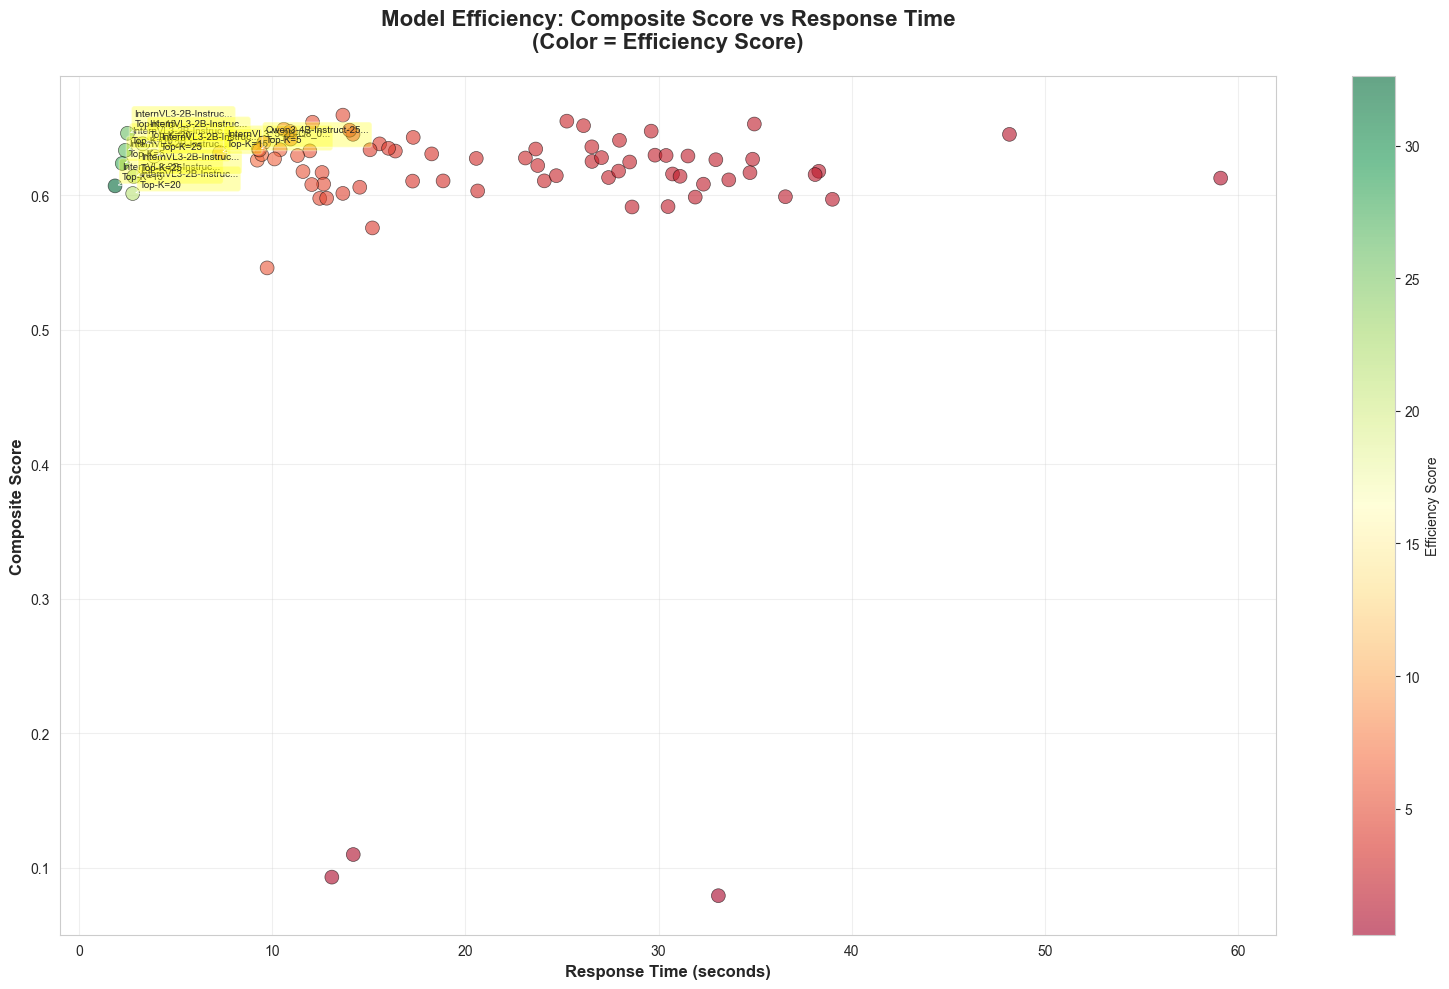


🏆 TOP 10 MOST EFFICIENT MODELS (Quality/Speed Balance)


,model,top_k,composite_score,response_time_mean,efficiency_score
3,InternVL3-2B-Instruct-Q5_K_M,15,0.606843,1.859720,32.630911
0,InternVL3-2B-Instruct-Q5_K_M,5,0.623520,2.232938,27.923763
1,InternVL3-2B-Instruct-Q5_K_M,10,0.633278,2.391603,26.479204
2,InternVL3-2B-Instruct-Q5_K_M,15,0.645945,2.502656,25.810375
5,InternVL3-2B-Instruct-Q5_K_M,20,0.601153,2.774388,21.667950
7,InternVL3-2B-Instruct-Q5_K_M,25,0.613842,2.836992,21.637079
4,InternVL3-2B-Instruct-Q5_K_M,20,0.638107,3.289441,19.398629
6,InternVL3-2B-Instruct-Q5_K_M,25,0.628948,3.880822,16.206570
20,InternVL3_5-2B-Q8_0,15,0.631524,7.277895,8.677295
50,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,5,0.634034,9.284029,6.829303



📊 Efficiency Score Formula: (composite_score / response_time) × 100
   Higher score = Better quality-to-speed ratio
   Interpretation: Quality points per second of response time


In [14]:
# Speed-Composite Score Scatter Plot with Efficiency Analysis

# Efficiency score: Simple formula - quality per second * 100 (higher is better)
# Formula: (composite_score / response_time_mean) * 100
# This represents how much quality you get per second of response time
df_latest['efficiency_score'] = (df_latest['composite_score'] / df_latest['response_time_mean']) * 100

# Create scatter plot
plt.figure(figsize=(16, 10))

# Color by efficiency score
scatter = plt.scatter(df_latest['response_time_mean'], 
                     df_latest['composite_score'],
                     c=df_latest['efficiency_score'], 
                     s=100, 
                     alpha=0.6, 
                     cmap='RdYlGn',
                     edgecolors='black',
                     linewidth=0.5)

# Add colorbar
cbar = plt.colorbar(scatter, label='Efficiency Score')
cbar.ax.tick_params(labelsize=10)

# Annotate top 10 efficiency models
top_efficiency = df_latest.nlargest(10, 'efficiency_score')
for idx, row in top_efficiency.iterrows():
    plt.annotate(f"{row['model'][:20]}...\nTop-K={row['top_k']}", 
                xy=(row['response_time_mean'], row['composite_score']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=0.5))

plt.xlabel('Response Time (seconds)', fontsize=12, fontweight='bold')
plt.ylabel('Composite Score', fontsize=12, fontweight='bold')
plt.title('Model Efficiency: Composite Score vs Response Time\n(Color = Efficiency Score)', 
         fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display top 10 most efficient models
print("\n" + "="*80)
print("🏆 TOP 10 MOST EFFICIENT MODELS (Quality/Speed Balance)")
print("="*80)
top_eff = df_latest.nlargest(10, 'efficiency_score')[['model', 'top_k', 'composite_score', 
                                                        'response_time_mean', 'efficiency_score']]
display(top_eff)

print(f"\n📊 Efficiency Score Formula: (composite_score / response_time) × 100")
print(f"   Higher score = Better quality-to-speed ratio")
print(f"   Interpretation: Quality points per second of response time")

### 8.3 Model Performance Ranking

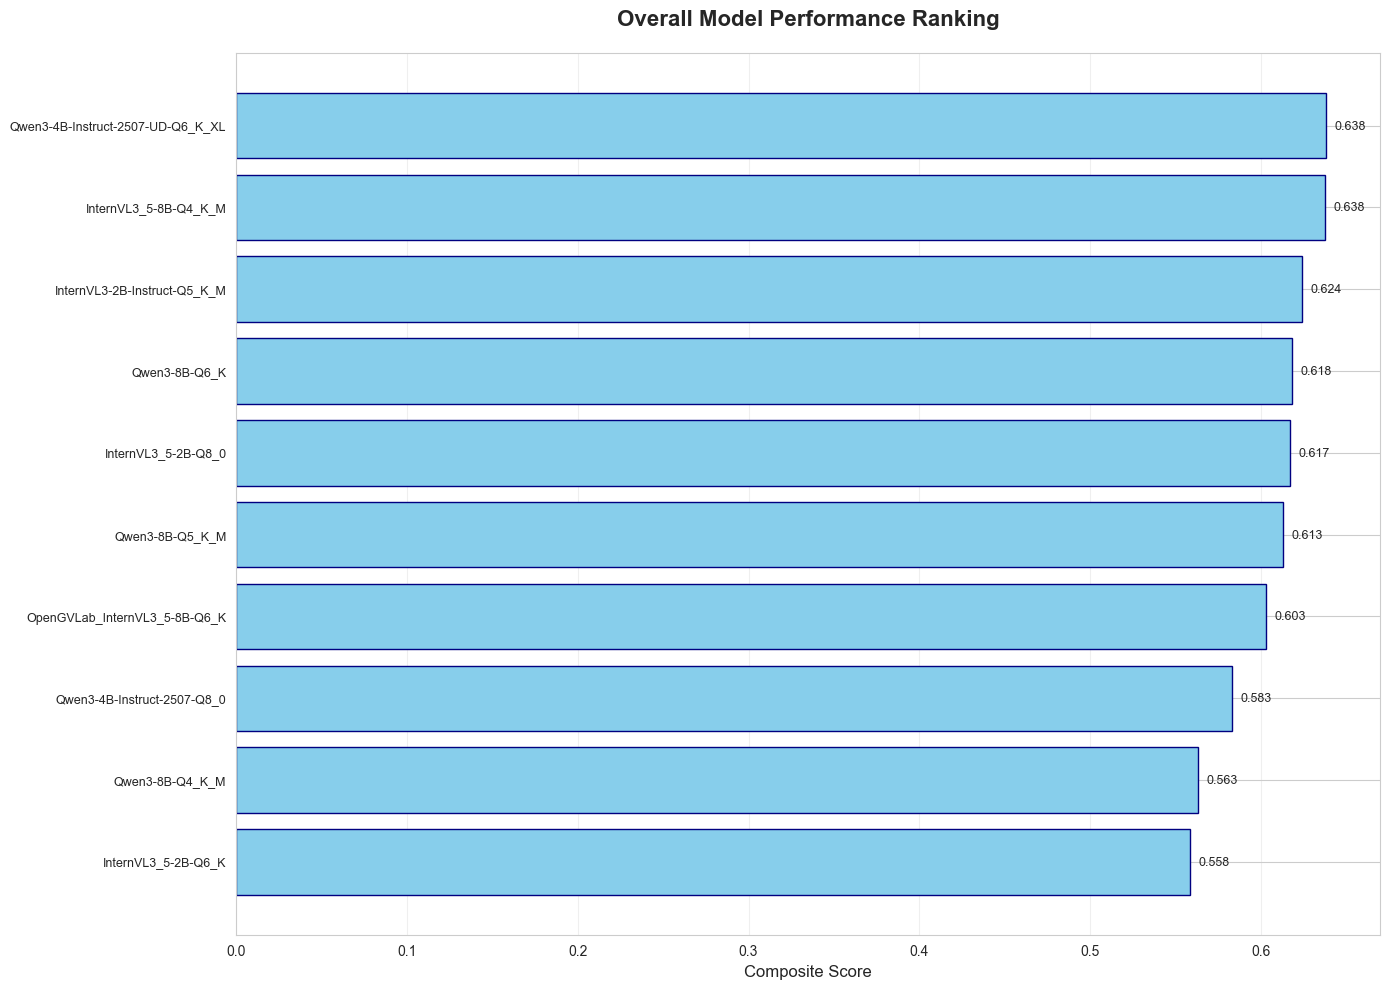

In [15]:
plt.figure(figsize=(14, 10))

model_scores = df_latest.groupby('model').agg({
    'semantic_sim_mean': 'mean',
    'bleu_mean': 'mean',
    'tfidf_mean': 'mean'
}).reset_index()

model_scores['composite_score'] = (
    model_scores['semantic_sim_mean'] * 0.6 +
    model_scores['tfidf_mean'] * 0.2 +
    model_scores['bleu_mean'] * 0.2
)

model_scores = model_scores.sort_values('composite_score', ascending=True)

y_pos = np.arange(len(model_scores))
plt.barh(y_pos, model_scores['composite_score'], color='skyblue', edgecolor='navy')
plt.yticks(y_pos, model_scores['model'], fontsize=9)
plt.xlabel('Composite Score', fontsize=12)
plt.title('Overall Model Performance Ranking', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(model_scores['composite_score']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.4 Multi-Metric Comparison for Top Models

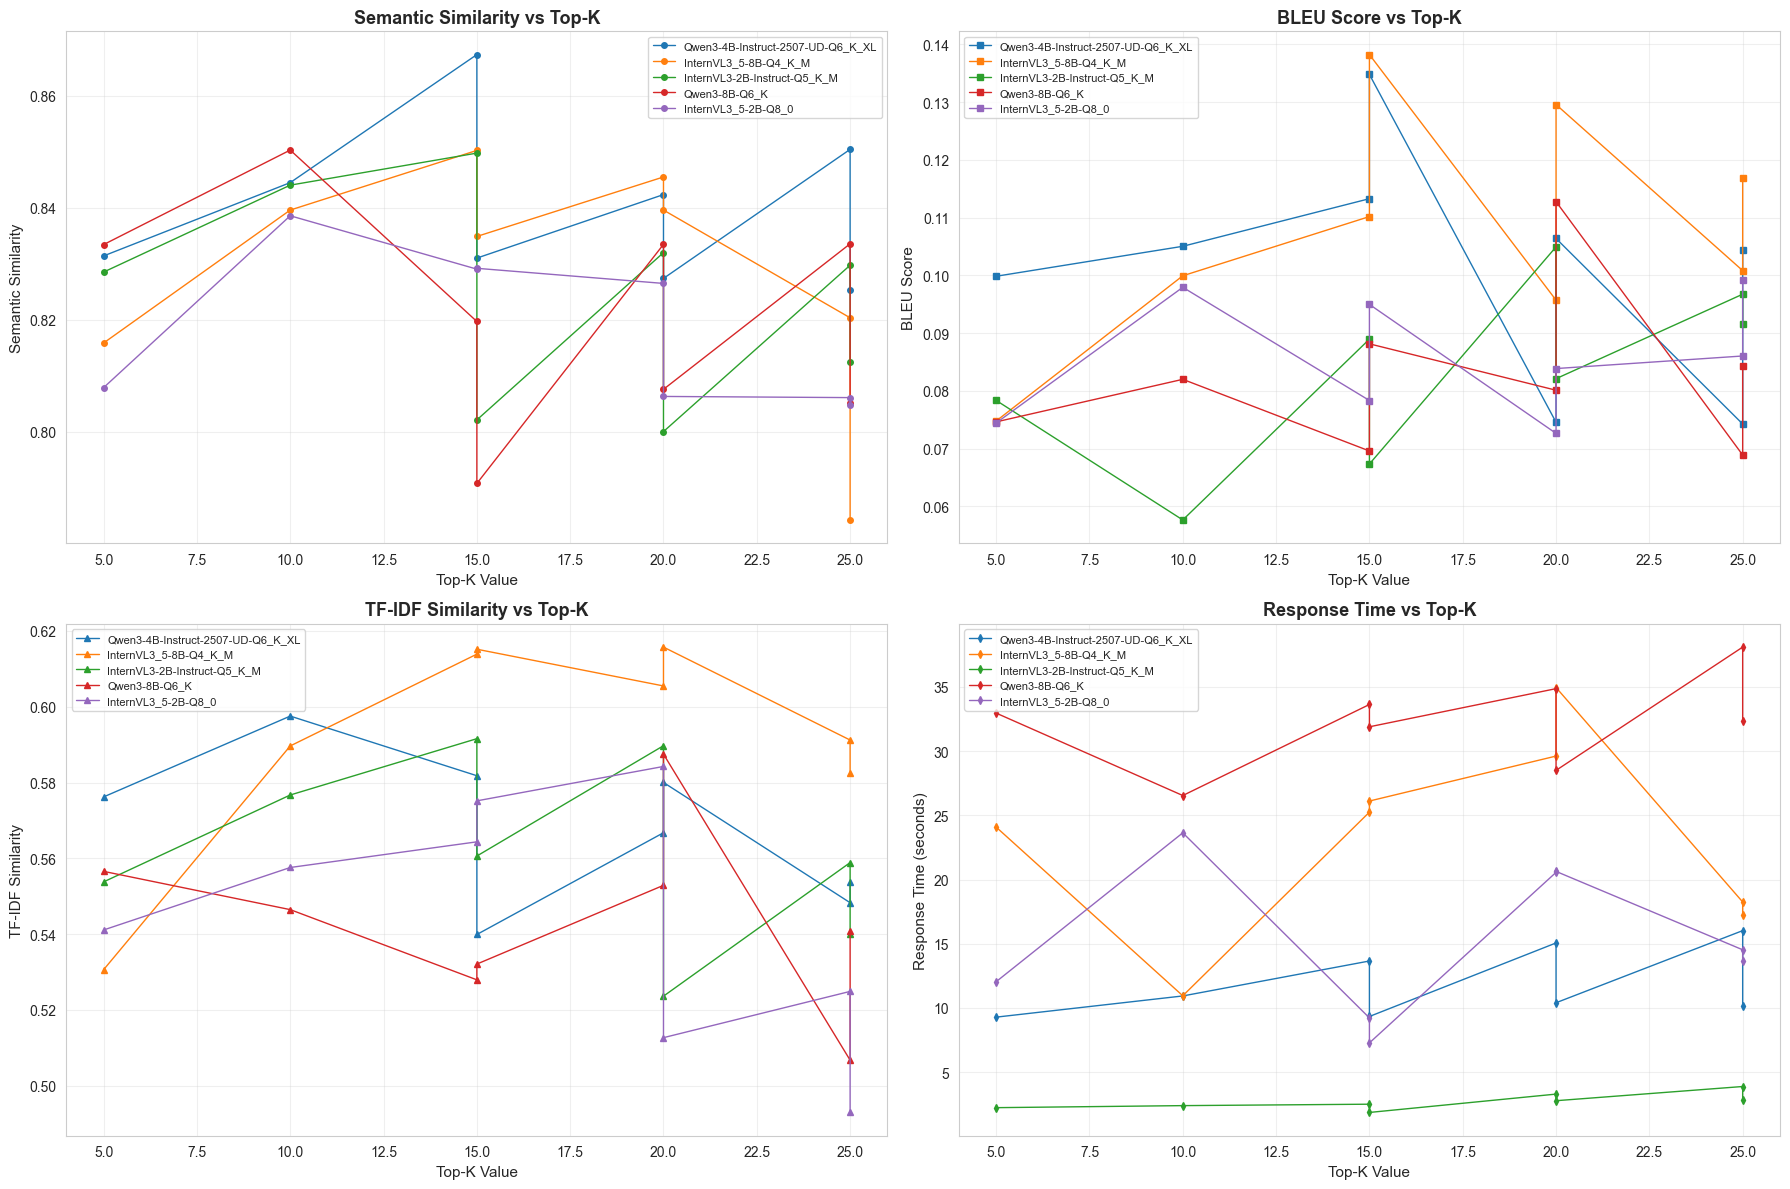

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Get top 5 models by composite score
top_models = df_latest.groupby('model')['composite_score'].mean().nlargest(5).index
df_top = df_latest[df_latest['model'].isin(top_models)]

# Semantic Similarity vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[0, 0].plot(model_data['top_k'], model_data['semantic_sim_mean'], 
                    marker='o', label=model, linewidth=1, markersize=4)
axes[0, 0].set_title('Semantic Similarity vs Top-K', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Top-K Value', fontsize=11)
axes[0, 0].set_ylabel('Semantic Similarity', fontsize=11)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# BLEU Score vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[0, 1].plot(model_data['top_k'], model_data['bleu_mean'], 
                    marker='s', label=model, linewidth=1, markersize=4)
axes[0, 1].set_title('BLEU Score vs Top-K', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Top-K Value', fontsize=11)
axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# TF-IDF Similarity vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[1, 0].plot(model_data['top_k'], model_data['tfidf_mean'], 
                    marker='^', label=model, linewidth=1, markersize=4)
axes[1, 0].set_title('TF-IDF Similarity vs Top-K', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Top-K Value', fontsize=11)
axes[1, 0].set_ylabel('TF-IDF Similarity', fontsize=11)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Response Time vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[1, 1].plot(model_data['top_k'], model_data['response_time_mean'], 
                    marker='d', label=model, linewidth=1, markersize=4)
axes[1, 1].set_title('Response Time vs Top-K', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Top-K Value', fontsize=11)
axes[1, 1].set_ylabel('Response Time (seconds)', fontsize=11)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.5 Distribution Plots

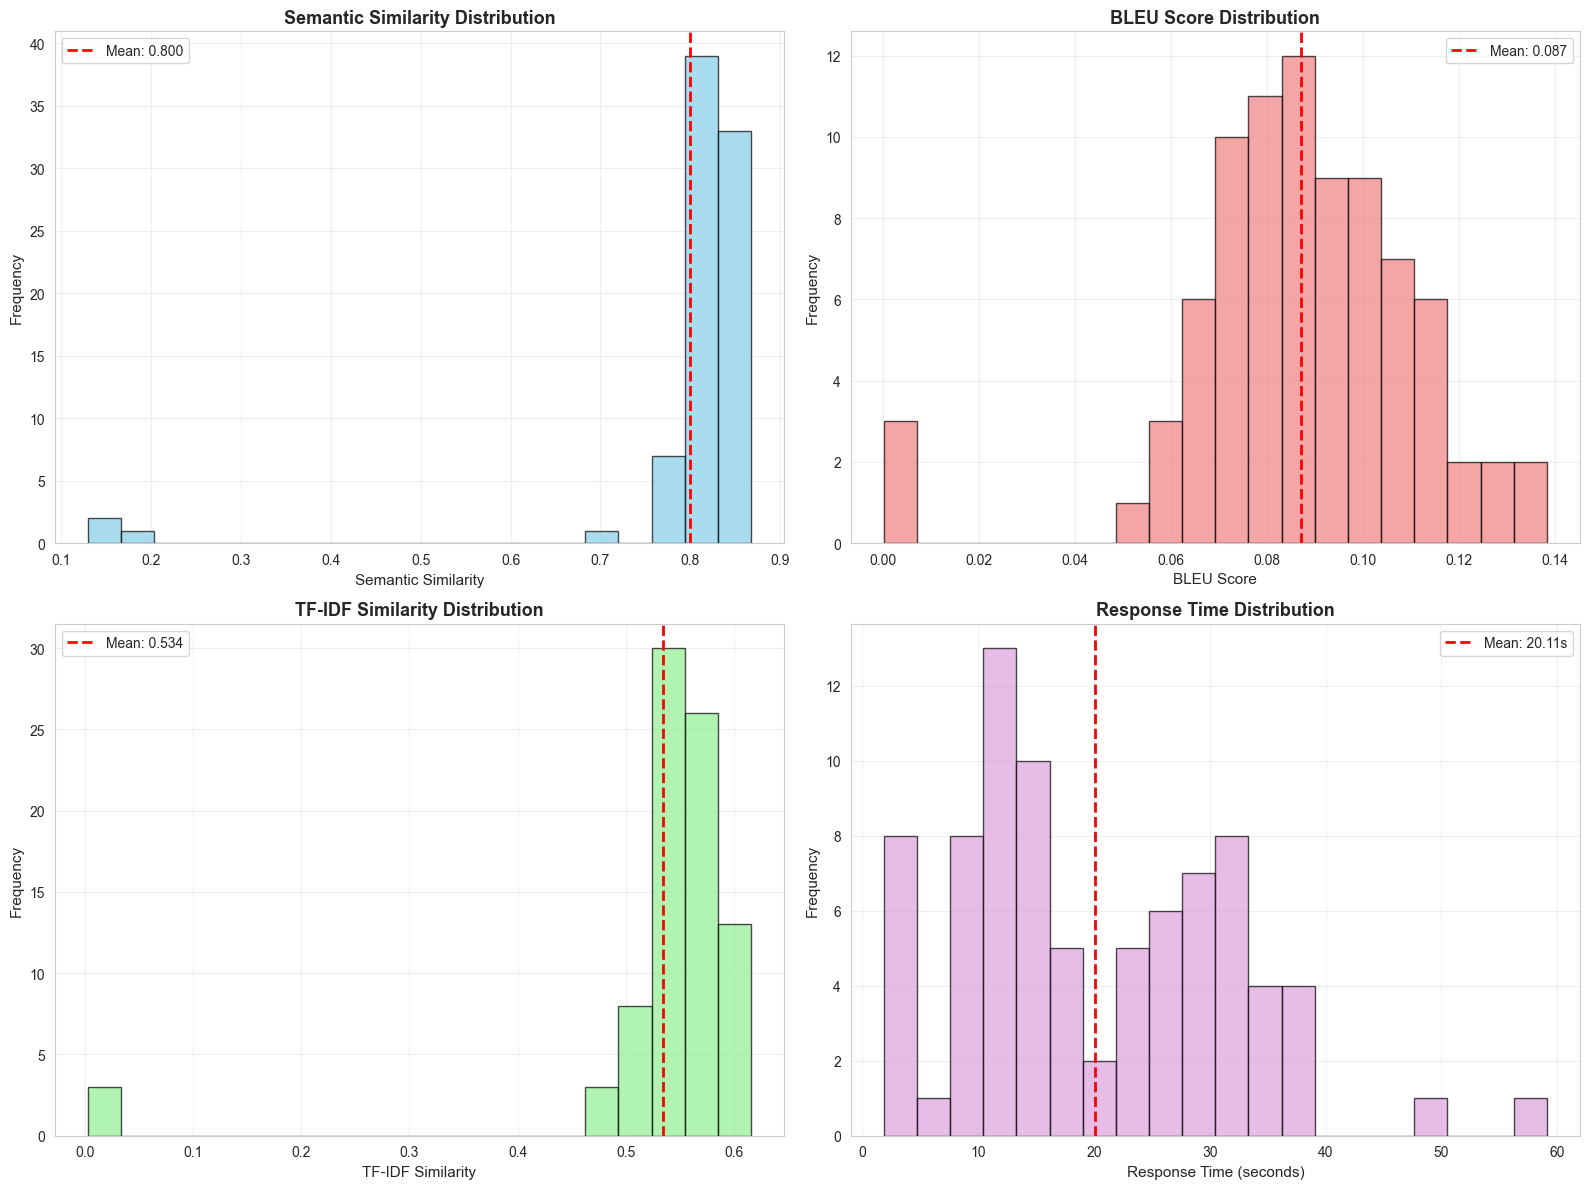

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Semantic Similarity Distribution
axes[0, 0].hist(df_latest['semantic_sim_mean'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_latest['semantic_sim_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['semantic_sim_mean'].mean():.3f}")
axes[0, 0].set_title('Semantic Similarity Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Semantic Similarity', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# BLEU Score Distribution
axes[0, 1].hist(df_latest['bleu_mean'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_latest['bleu_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['bleu_mean'].mean():.3f}")
axes[0, 1].set_title('BLEU Score Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('BLEU Score', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# TF-IDF Distribution
axes[1, 0].hist(df_latest['tfidf_mean'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df_latest['tfidf_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['tfidf_mean'].mean():.3f}")
axes[1, 0].set_title('TF-IDF Similarity Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('TF-IDF Similarity', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Response Time Distribution
axes[1, 1].hist(df_latest['response_time_mean'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df_latest['response_time_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['response_time_mean'].mean():.2f}s")
axes[1, 1].set_title('Response Time Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Response Time (seconds)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.6 Distribution Analysis by Model

Visualize metric distributions for each individual model.

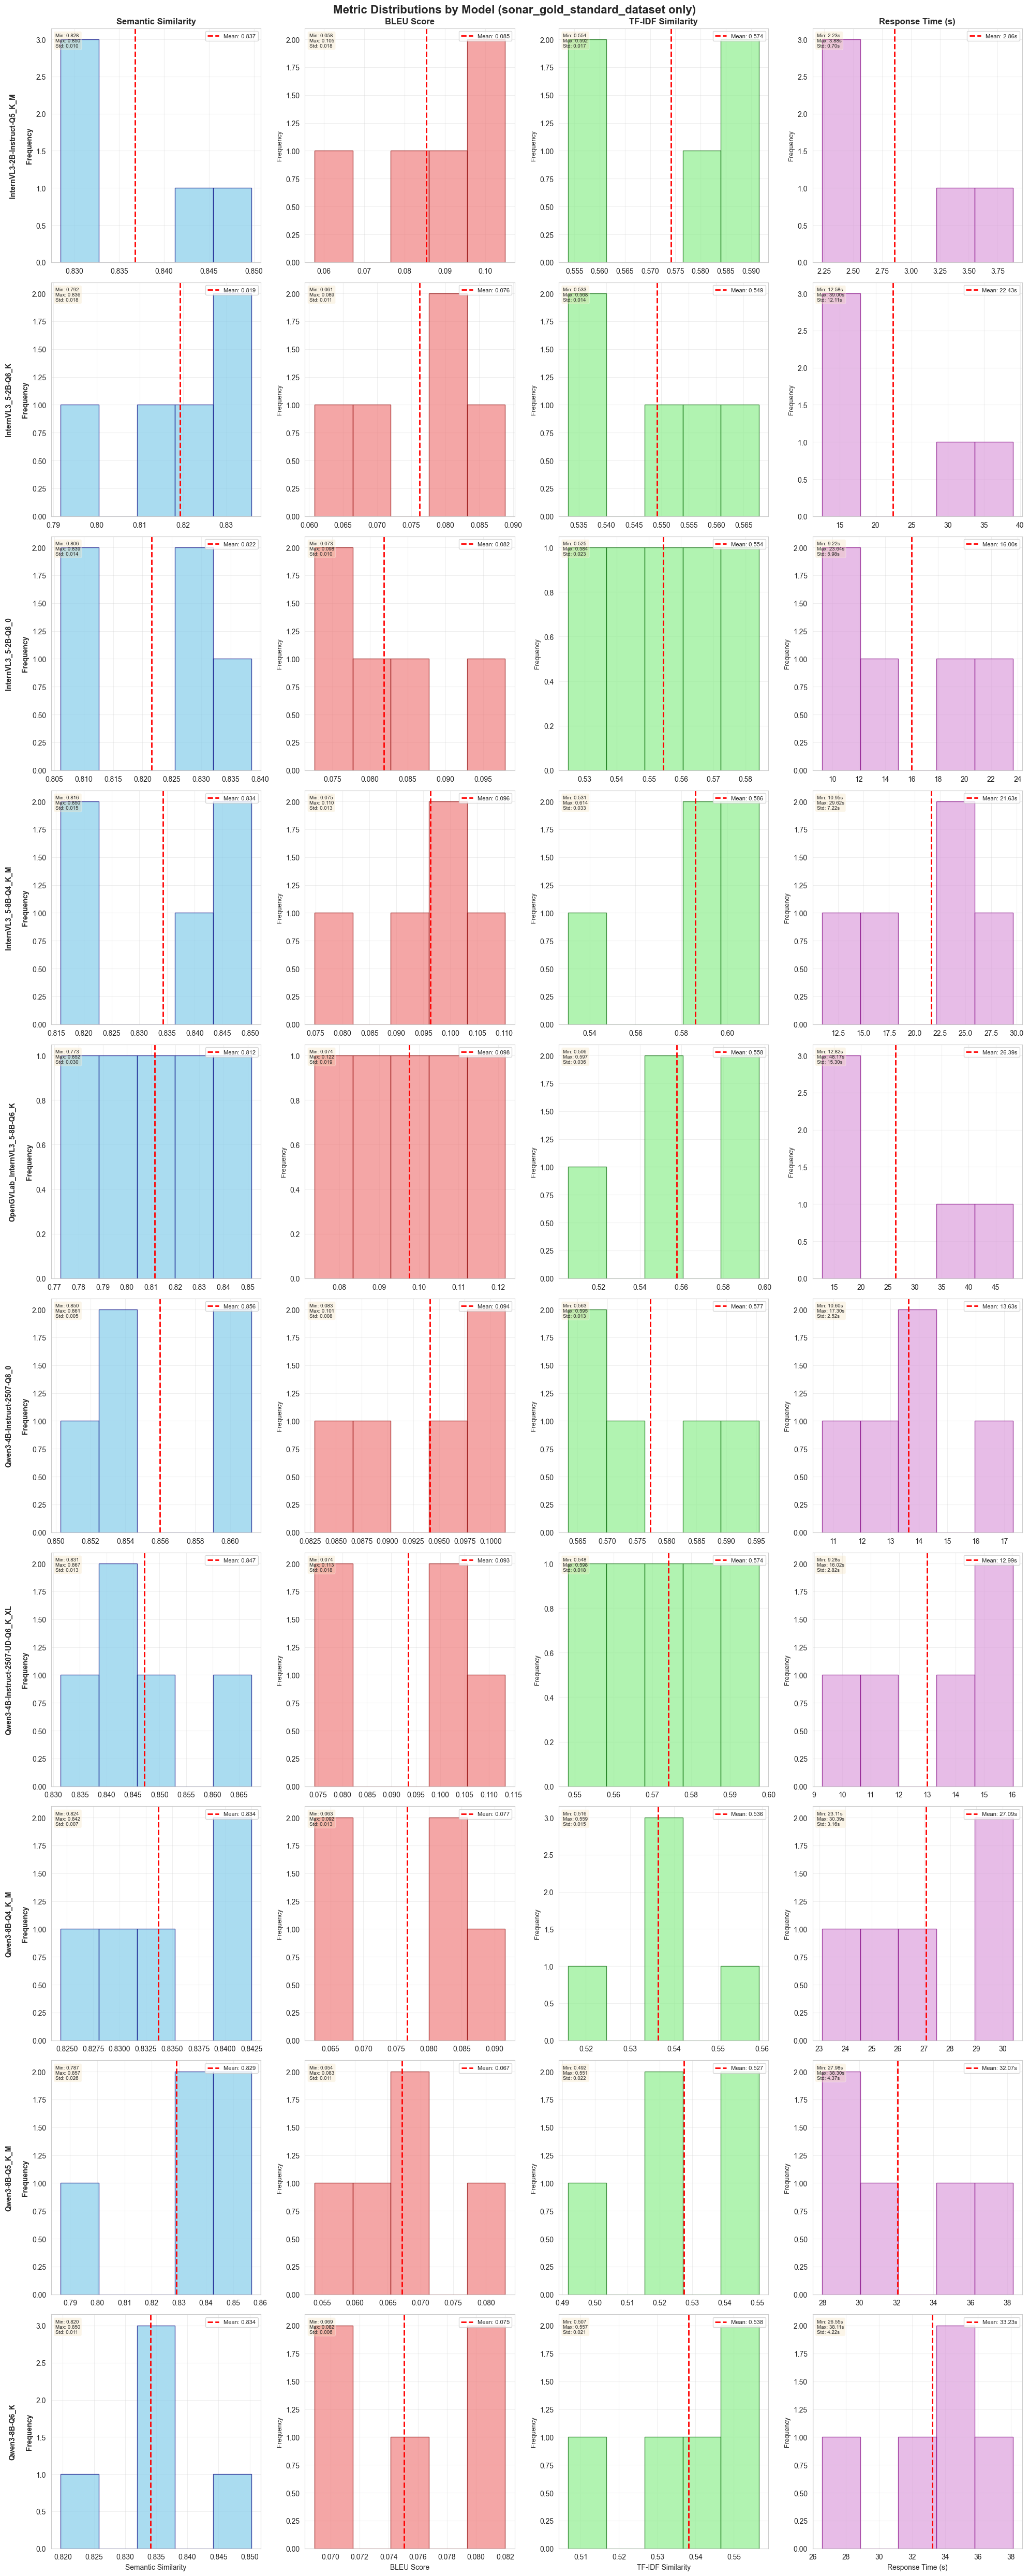

In [18]:
# Filter for sonar_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_gold_standard_dataset', case=False, na=False)]

# Get all unique models
all_models = sorted(df_sonar['model'].unique())
n_models = len(all_models)

# Create subplots - 4 metrics per model
fig, axes = plt.subplots(n_models, 4, figsize=(20, 5*n_models))

# If only one model, ensure axes is 2D
if n_models == 1:
    axes = axes.reshape(1, -1)

metrics_info = [
    ('semantic_sim_mean', 'Semantic Similarity', 'skyblue', 'navy'),
    ('bleu_mean', 'BLEU Score', 'lightcoral', 'darkred'),
    ('tfidf_mean', 'TF-IDF Similarity', 'lightgreen', 'darkgreen'),
    ('response_time_mean', 'Response Time (s)', 'plum', 'purple')
]

for model_idx, model in enumerate(all_models):
    model_data = df_sonar[df_sonar['model'] == model]
    
    for metric_idx, (metric, label, color, edge_color) in enumerate(metrics_info):
        ax = axes[model_idx, metric_idx]
        
        # Plot histogram
        values = model_data[metric].dropna()
        ax.hist(values, bins=min(15, len(values)), color=color, edgecolor=edge_color, alpha=0.7)
        
        # Add mean line
        mean_val = values.mean()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_val:.3f}' if metric != 'response_time_mean' else f'Mean: {mean_val:.2f}s')
        
        # Formatting
        if metric_idx == 0:
            ax.set_ylabel(f'{model}\n\nFrequency', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('Frequency', fontsize=9)
        
        if model_idx == 0:
            ax.set_title(label, fontsize=12, fontweight='bold')
        
        if model_idx == n_models - 1:
            ax.set_xlabel(label, fontsize=10)
        
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Min: {values.min():.3f}\nMax: {values.max():.3f}\nStd: {values.std():.3f}'
        if metric == 'response_time_mean':
            stats_text = f'Min: {values.min():.2f}s\nMax: {values.max():.2f}s\nStd: {values.std():.2f}s'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Metric Distributions by Model (sonar_gold_standard_dataset only)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


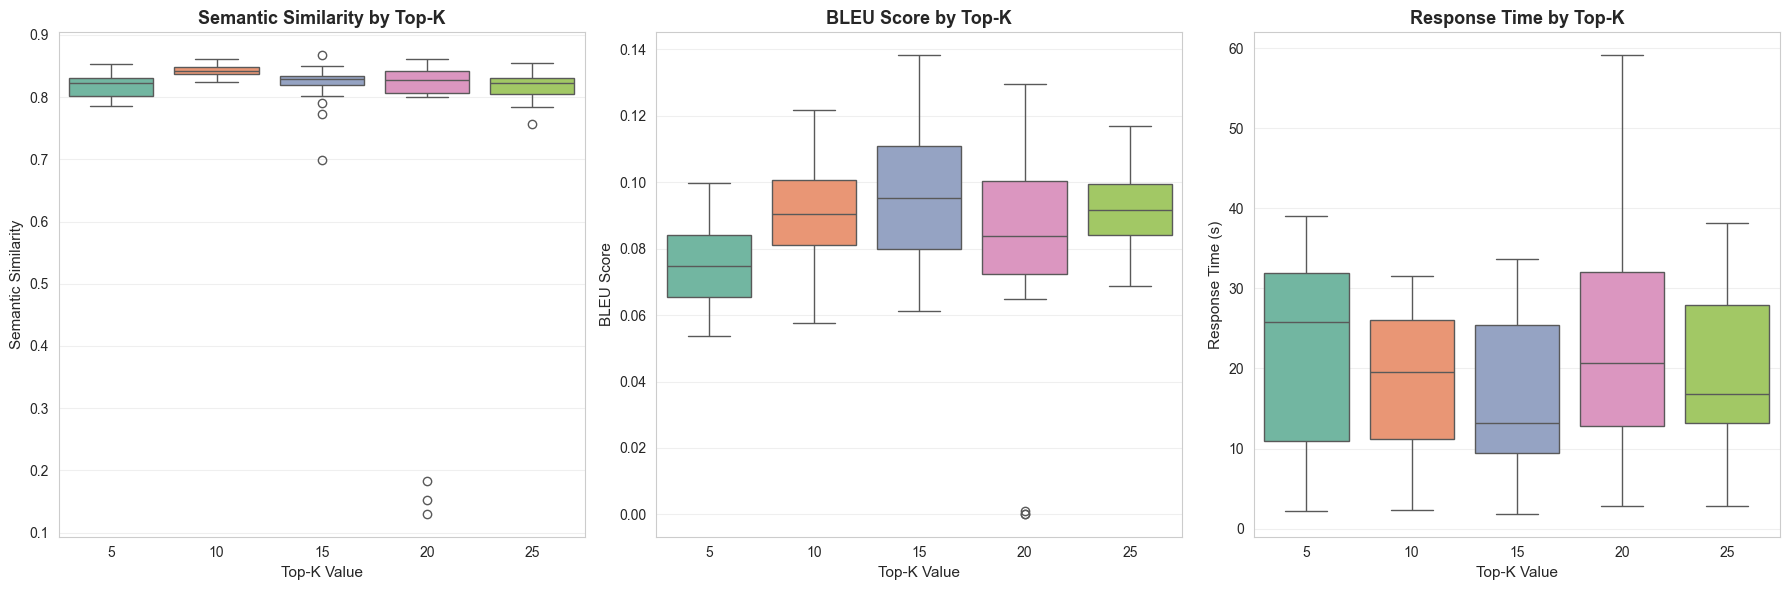

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Semantic Similarity by Top-K
sns.boxplot(data=df_latest, x='top_k', y='semantic_sim_mean', ax=axes[0], palette='Set2')
axes[0].set_title('Semantic Similarity by Top-K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Top-K Value', fontsize=11)
axes[0].set_ylabel('Semantic Similarity', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# BLEU Score by Top-K
sns.boxplot(data=df_latest, x='top_k', y='bleu_mean', ax=axes[1], palette='Set2')
axes[1].set_title('BLEU Score by Top-K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Top-K Value', fontsize=11)
axes[1].set_ylabel('BLEU Score', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Response Time by Top-K
sns.boxplot(data=df_latest, x='top_k', y='response_time_mean', ax=axes[2], palette='Set2')
axes[2].set_title('Response Time by Top-K', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Top-K Value', fontsize=11)
axes[2].set_ylabel('Response Time (s)', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

# Golden Dataset Comparison Analysis

Compare performance across different golden standard datasets to understand how reference data affects evaluation metrics.

## 9. Identify Golden Datasets

First, let's identify all unique golden standard datasets used in the evaluations.

In [20]:
# For dataset comparison, use ALL datasets including irrelevant_info
# (We filtered it out for general analysis above)
unique_gold_datasets = df_latest_all['gold_standard_path'].unique()

print("\n⚠️ Note: Now including ALL golden datasets for comparison analysis")
print("   (including irrelevant_info_standard_dataset that was excluded earlier)\n")

print("="*80)
print("GOLDEN STANDARD DATASETS FOUND")
print("="*80)

for i, path in enumerate(unique_gold_datasets, 1):
    count_all = len(df_all[df_all['gold_standard_path'] == path])
    count_latest = len(df_latest_all[df_latest_all['gold_standard_path'] == path])
    
    # Extract dataset name from path
    dataset_name = Path(path).stem if path else "Unknown"
    
    print(f"\n{i}. {dataset_name}")
    print(f"   Path: {path}")
    print(f"   Total experiments: {count_all}")
    print(f"   Latest unique configs: {count_latest}")

# Create a simplified name for each dataset for easier analysis
def get_dataset_name(path):
    if pd.isna(path) or not path:
        return "Unknown"
    name = Path(path).stem
    # Fix spelling mistake: unrelevant -> irrelevant
    if 'unrelevant' in name.lower():
        name = name.replace('unrelevant', 'irrelevant').replace('Unrelevant', 'Irrelevant')
    return name

df_all['dataset_name'] = df_all['gold_standard_path'].apply(get_dataset_name)
df_latest['dataset_name'] = df_latest['gold_standard_path'].apply(get_dataset_name)
df_latest_all['dataset_name'] = df_latest_all['gold_standard_path'].apply(get_dataset_name)

print("\n" + "="*80)
print(f"Total unique golden datasets: {len(unique_gold_datasets)}")
print("="*80)


⚠️ Note: Now including ALL golden datasets for comparison analysis
   (including irrelevant_info_standard_dataset that was excluded earlier)

GOLDEN STANDARD DATASETS FOUND

1. sonar_gold_standard_dataset
   Path: data/test/sonar_gold_standard_dataset.json
   Total experiments: 50
   Latest unique configs: 50

2. sonar_reasoning_pro_gold_standard_dataset
   Path: data/test/sonar_reasoning_pro_gold_standard_dataset.json
   Total experiments: 30
   Latest unique configs: 30

3. unrelevant_info_standard_dataset
   Path: data/test/unrelevant_info_standard_dataset.json
   Total experiments: 6
   Latest unique configs: 3

Total unique golden datasets: 3


## 10. Statistical Comparison by Golden Dataset

Compare key metrics across different golden datasets.

In [21]:
if len(unique_gold_datasets) > 1:
    print("="*80)
    print("PERFORMANCE METRICS BY GOLDEN DATASET")
    print("="*80)
    
    # Use df_latest_all to include ALL datasets for comparison
    # Aggregate statistics by golden dataset
    dataset_comparison = df_latest_all.groupby('dataset_name').agg({
        'semantic_sim_mean': ['mean', 'std', 'min', 'max', 'count'],
        'bleu_mean': ['mean', 'std', 'min', 'max'],
        'tfidf_mean': ['mean', 'std', 'min', 'max'],
        'response_time_mean': ['mean', 'std', 'min', 'max'],
        'composite_score': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    display(dataset_comparison)
    
    # Summary table
    print("\n" + "="*80)
    print("SUMMARY COMPARISON")
    print("="*80)
    
    summary = df_latest_all.groupby('dataset_name')[['semantic_sim_mean', 'bleu_mean', 
                                                   'tfidf_mean', 'response_time_mean', 
                                                   'composite_score']].mean().round(4)
    display(summary)
    
    # Best configuration per dataset
    print("\n" + "="*80)
    print("BEST CONFIGURATION PER GOLDEN DATASET")
    print("="*80)
    
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_df = df_latest_all[df_latest_all['dataset_name'] == dataset]
        best = dataset_df.nlargest(1, 'composite_score').iloc[0]
        
        print(f"\n📊 Dataset: {dataset}")
        print(f"   Best Model: {best['model']}")
        print(f"   Top-K: {best['top_k']}")
        print(f"   Semantic Similarity: {best['semantic_sim_mean']:.4f}")
        print(f"   BLEU Score: {best['bleu_mean']:.4f}")
        print(f"   Composite Score: {best['composite_score']:.4f}")
        print(f"   Response Time: {best['response_time_mean']:.2f}s")
else:
    print("="*80)
    print("Only one golden dataset found in the logs.")
    print("No comparison needed.")
    print("="*80)

PERFORMANCE METRICS BY GOLDEN DATASET


semantic_sim_mean                  \
                                                       mean     std     min   
dataset_name                                                                  
irrelevant_info_standard_dataset                     0.1549  0.0262  0.1301   
sonar_gold_standard_dataset                          0.8324  0.0197  0.7726   
sonar_reasoning_pro_gold_standard_dataset            0.8103  0.0280  0.6984   

                                                        bleu_mean          \
                                              max count      mean     std   
dataset_name                                                                
irrelevant_info_standard_dataset           0.1823     3    0.0004  0.0004   
sonar_gold_standard_dataset                0.8673    50    0.0844  0.0158   
sonar_reasoning_pro_gold_standard_dataset  0.8411    30    0.1004  0.0187   

                                                          tfidf_mean  ...  \
                                              min     max       mean  ...   
dataset_name                                                          ...   
irrelevant_info_standard_dataset           0.0002  0.0009     0.0055  ...   
sonar_gold_standard_dataset                0.0538  0.1217     0.5575  ...   
sonar_reasoning_pro_gold_standard_dataset  0.0649  0.1382     0.5479  ...   

                                                          response_time_mean  \
                                              min     max               mean   
dataset_name                                                                   
irrelevant_info_standard_dataset           0.0027  0.0079            20.1244   
sonar_gold_standard_dataset                0.4918  0.6139            20.8318   
sonar_reasoning_pro_gold_standard_dataset  0.4849  0.6157            18.9060   

                                                                      \
                                               std      min      max   
dataset_name                                                           
irrelevant_info_standard_dataset           11.2477  13.0840  33.0964   
sonar_gold_standard_dataset                11.2350   2.2329  48.1677   
sonar_reasoning_pro_gold_standard_dataset  12.5589   1.8597  59.1038   

                                          composite_score                  \
                                                     mean     std     min   
dataset_name                                                                
irrelevant_info_standard_dataset                   0.0941  0.0153  0.0793   
sonar_gold_standard_dataset                        0.6278  0.0165  0.5912   
sonar_reasoning_pro_gold_standard_dataset          0.6159  0.0218  0.5459   

                                                   
                                              max  
dataset_name                                       
irrelevant_info_standard_dataset           0.1099  
sonar_gold_standard_dataset                0.6594  
sonar_reasoning_pro_gold_standard_dataset  0.6528  

[3 rows x 21 columns]


SUMMARY COMPARISON


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
dataset_name,,,,,
irrelevant_info_standard_dataset,0.1549,0.0004,0.0055,20.1244,0.0941
sonar_gold_standard_dataset,0.8324,0.0844,0.5575,20.8318,0.6278
sonar_reasoning_pro_gold_standard_dataset,0.8103,0.1004,0.5479,18.9060,0.6159



BEST CONFIGURATION PER GOLDEN DATASET

📊 Dataset: sonar_gold_standard_dataset
   Best Model: Qwen3-4B-Instruct-2507-UD-Q6_K_XL
   Top-K: 15
   Semantic Similarity: 0.8673
   BLEU Score: 0.1133
   Composite Score: 0.6594
   Response Time: 13.66s

📊 Dataset: sonar_reasoning_pro_gold_standard_dataset
   Best Model: InternVL3_5-8B-Q4_K_M
   Top-K: 20
   Semantic Similarity: 0.8396
   BLEU Score: 0.1296
   Composite Score: 0.6528
   Response Time: 34.96s

📊 Dataset: irrelevant_info_standard_dataset
   Best Model: Qwen3-4B-Instruct-2507-Q8_0
   Top-K: 20
   Semantic Similarity: 0.1823
   BLEU Score: 0.0002
   Composite Score: 0.1099
   Response Time: 14.19s


## 11. Visualizations: Golden Dataset Comparisons

Create visualizations comparing performance across different golden datasets.

### 11.1 Metric Comparison Bar Charts

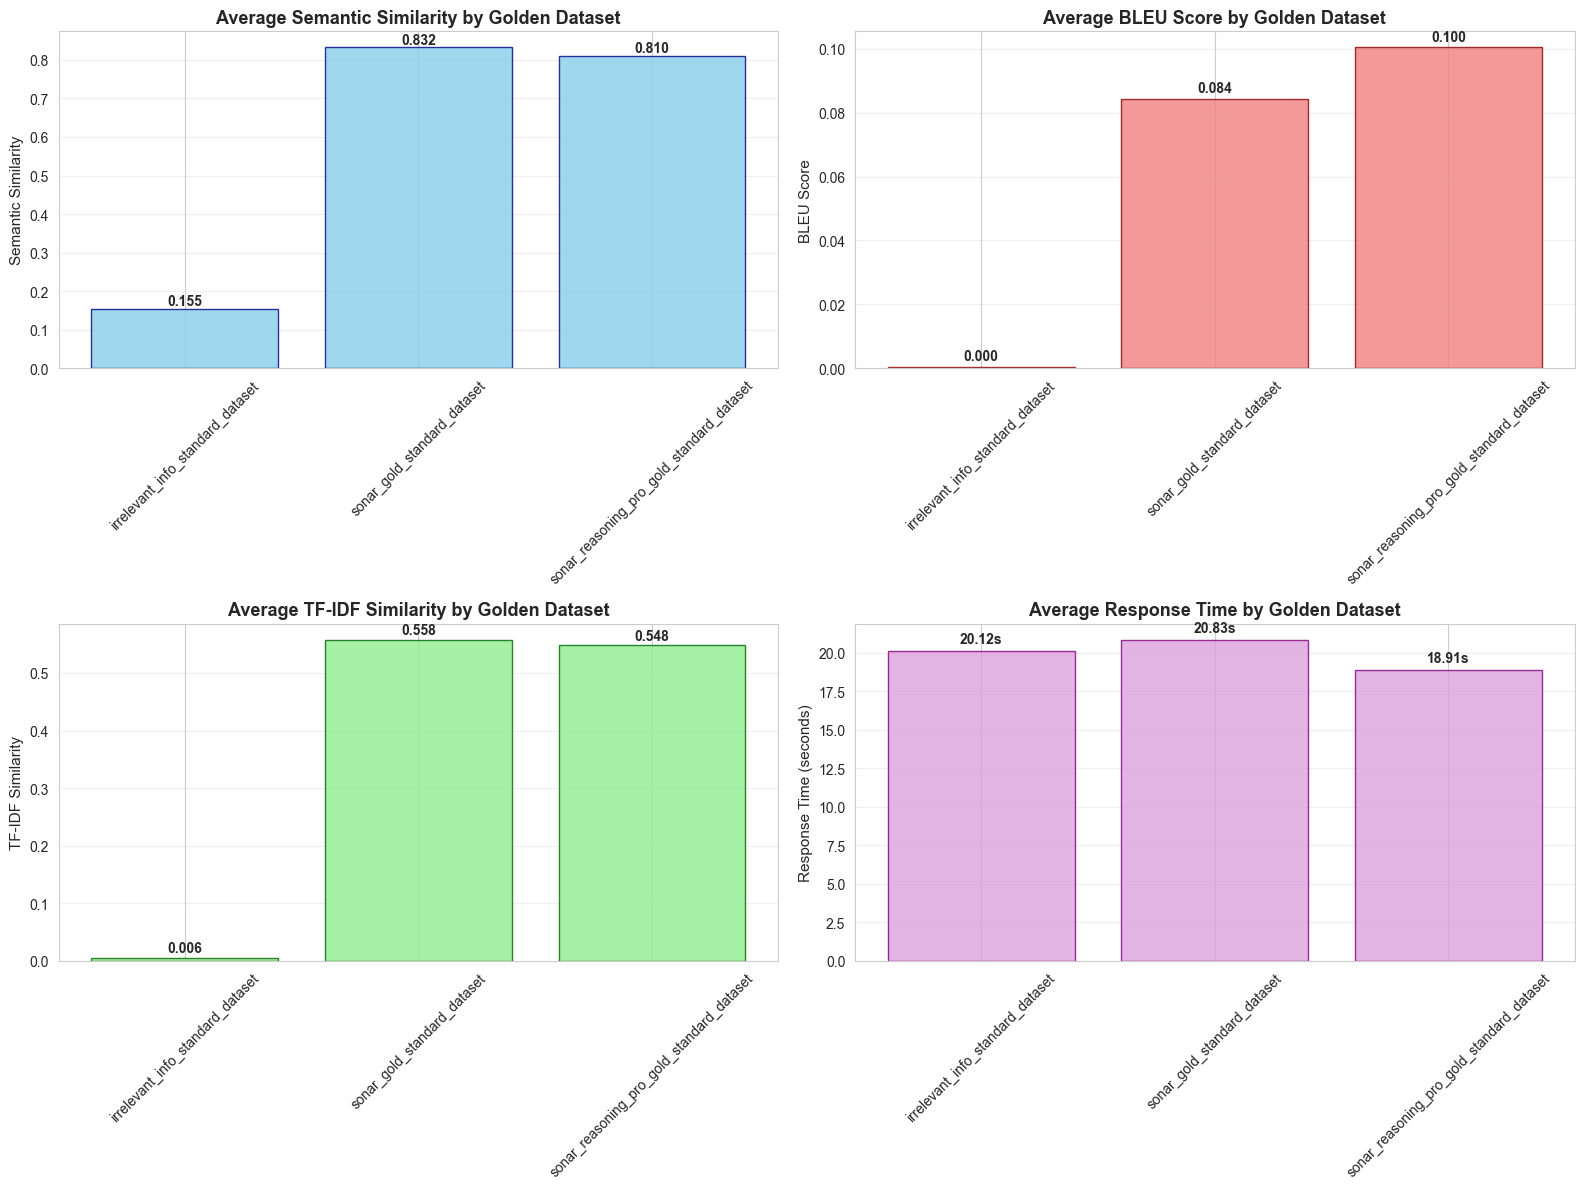

In [22]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    datasets_summary = df_latest_all.groupby('dataset_name').agg({
        'semantic_sim_mean': 'mean',
        'bleu_mean': 'mean',
        'tfidf_mean': 'mean',
        'response_time_mean': 'mean'
    }).reset_index()
    
    # Semantic Similarity
    axes[0, 0].bar(datasets_summary['dataset_name'], datasets_summary['semantic_sim_mean'], 
                   color='skyblue', edgecolor='navy', alpha=0.8)
    axes[0, 0].set_title('Average Semantic Similarity by Golden Dataset', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['semantic_sim_mean']):
        axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # BLEU Score
    axes[0, 1].bar(datasets_summary['dataset_name'], datasets_summary['bleu_mean'], 
                   color='lightcoral', edgecolor='darkred', alpha=0.8)
    axes[0, 1].set_title('Average BLEU Score by Golden Dataset', fontsize=13, fontweight='bold')
    axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['bleu_mean']):
        axes[0, 1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # TF-IDF Similarity
    axes[1, 0].bar(datasets_summary['dataset_name'], datasets_summary['tfidf_mean'], 
                   color='lightgreen', edgecolor='darkgreen', alpha=0.8)
    axes[1, 0].set_title('Average TF-IDF Similarity by Golden Dataset', fontsize=13, fontweight='bold')
    axes[1, 0].set_ylabel('TF-IDF Similarity', fontsize=11)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['tfidf_mean']):
        axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # Response Time
    axes[1, 1].bar(datasets_summary['dataset_name'], datasets_summary['response_time_mean'], 
                   color='plum', edgecolor='purple', alpha=0.8)
    axes[1, 1].set_title('Average Response Time by Golden Dataset', fontsize=13, fontweight='bold')
    axes[1, 1].set_ylabel('Response Time (seconds)', fontsize=11)
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['response_time_mean']):
        axes[1, 1].text(i, v + 0.5, f'{v:.2f}s', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 11.2 Box Plot Comparison Across Datasets

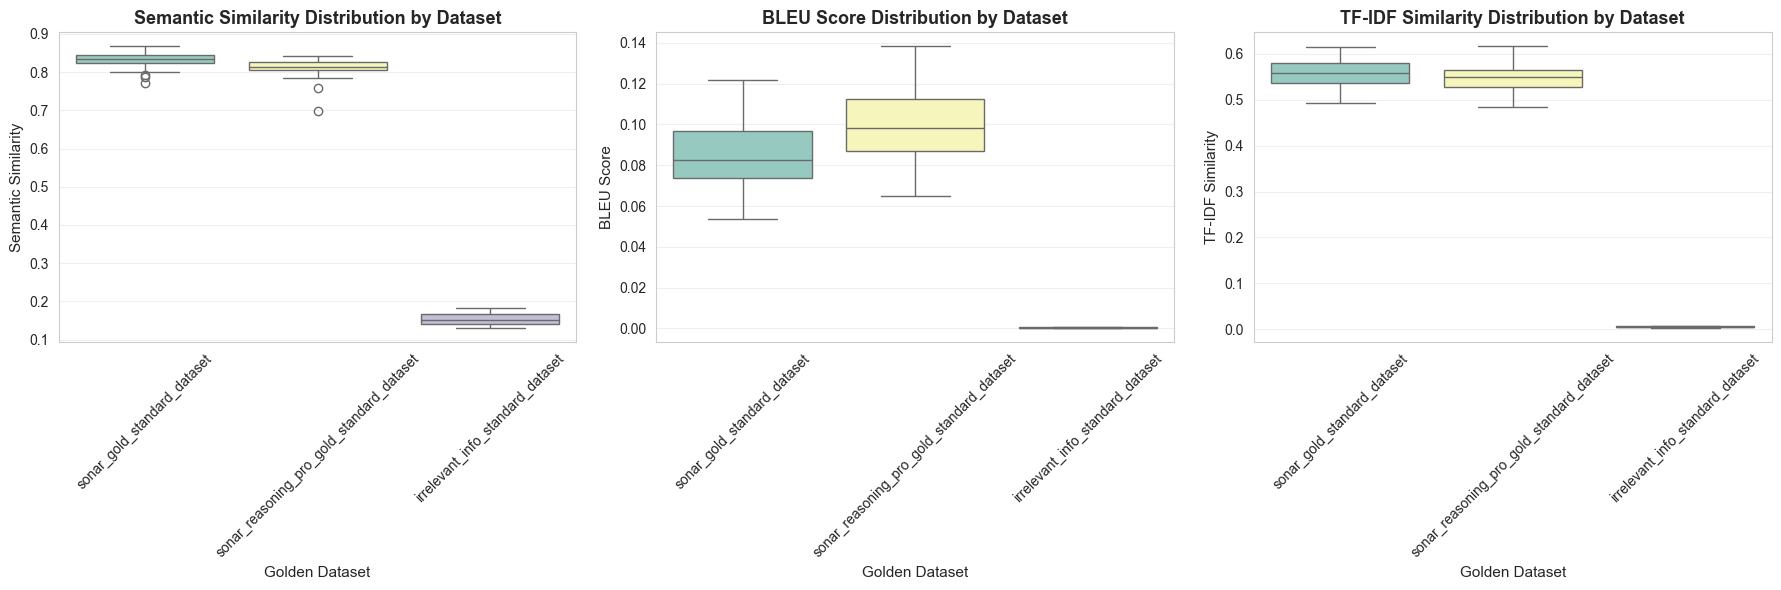

In [23]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Semantic Similarity
    sns.boxplot(data=df_latest_all, x='dataset_name', y='semantic_sim_mean', ax=axes[0], palette='Set3')
    axes[0].set_title('Semantic Similarity Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Golden Dataset', fontsize=11)
    axes[0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # BLEU Score
    sns.boxplot(data=df_latest_all, x='dataset_name', y='bleu_mean', ax=axes[1], palette='Set3')
    axes[1].set_title('BLEU Score Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Golden Dataset', fontsize=11)
    axes[1].set_ylabel('BLEU Score', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # TF-IDF Similarity
    sns.boxplot(data=df_latest_all, x='dataset_name', y='tfidf_mean', ax=axes[2], palette='Set3')
    axes[2].set_title('TF-IDF Similarity Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Golden Dataset', fontsize=11)
    axes[2].set_ylabel('TF-IDF Similarity', fontsize=11)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 11.3 Model Performance Across Datasets

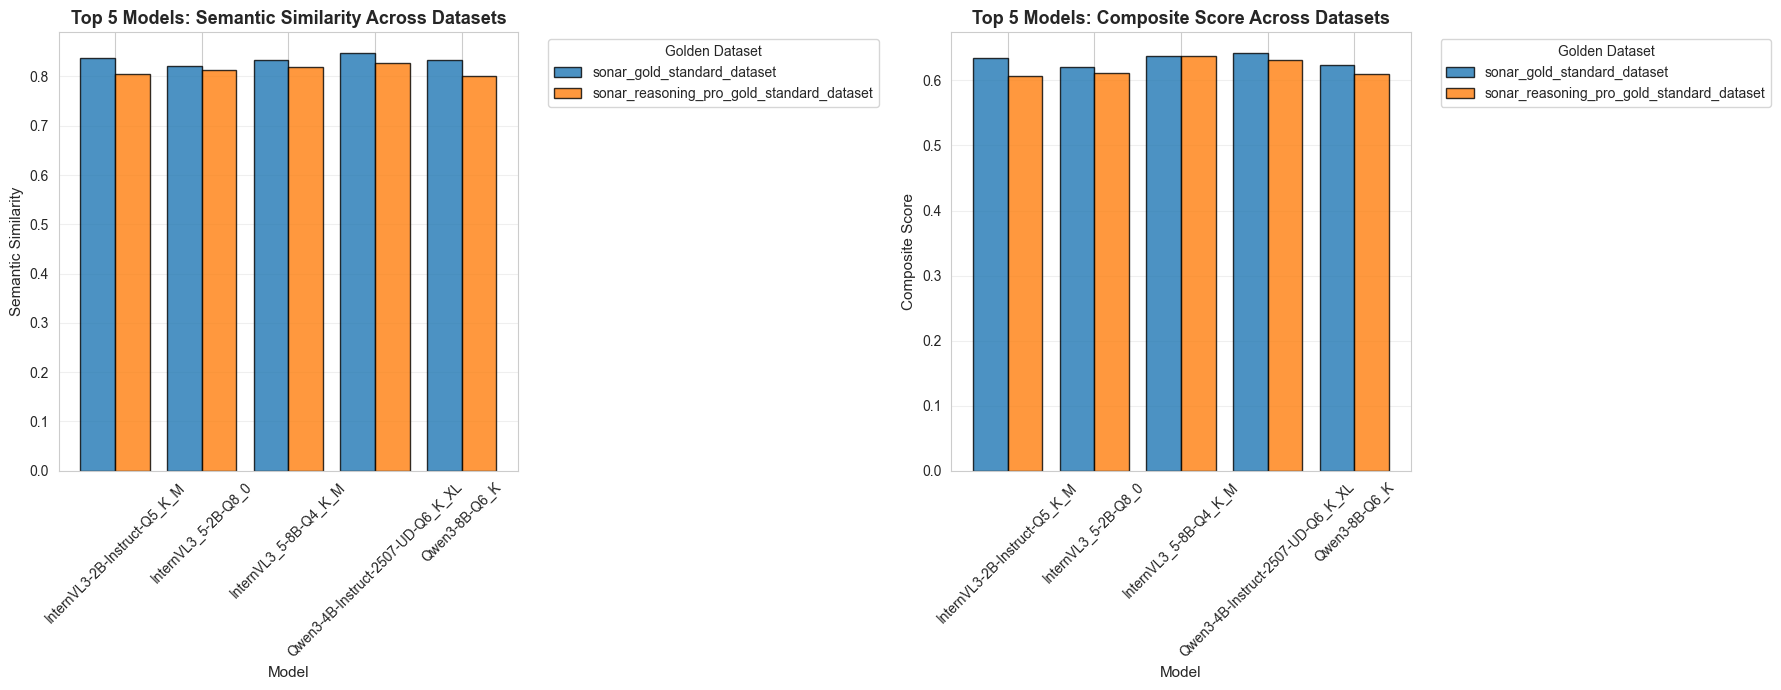

In [24]:
if len(unique_gold_datasets) > 1:
    # Get top 5 models overall
    top_models = df_latest.groupby('model')['composite_score'].mean().nlargest(5).index
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Filter data for top models
    df_top_models = df_latest[df_latest['model'].isin(top_models)]
    
    # Semantic Similarity comparison
    model_dataset_sem = df_top_models.pivot_table(
        values='semantic_sim_mean', 
        index='model', 
        columns='dataset_name', 
        aggfunc='mean'
    )
    
    model_dataset_sem.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black', alpha=0.8)
    axes[0].set_title('Top 5 Models: Semantic Similarity Across Datasets', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0].set_xlabel('Model', fontsize=11)
    axes[0].legend(title='Golden Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Composite Score comparison
    model_dataset_comp = df_top_models.pivot_table(
        values='composite_score', 
        index='model', 
        columns='dataset_name', 
        aggfunc='mean'
    )
    
    model_dataset_comp.plot(kind='bar', ax=axes[1], width=0.8, edgecolor='black', alpha=0.8)
    axes[1].set_title('Top 5 Models: Composite Score Across Datasets', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Composite Score', fontsize=11)
    axes[1].set_xlabel('Model', fontsize=11)
    axes[1].legend(title='Golden Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 11.4 Heatmap: Dataset vs Model Performance

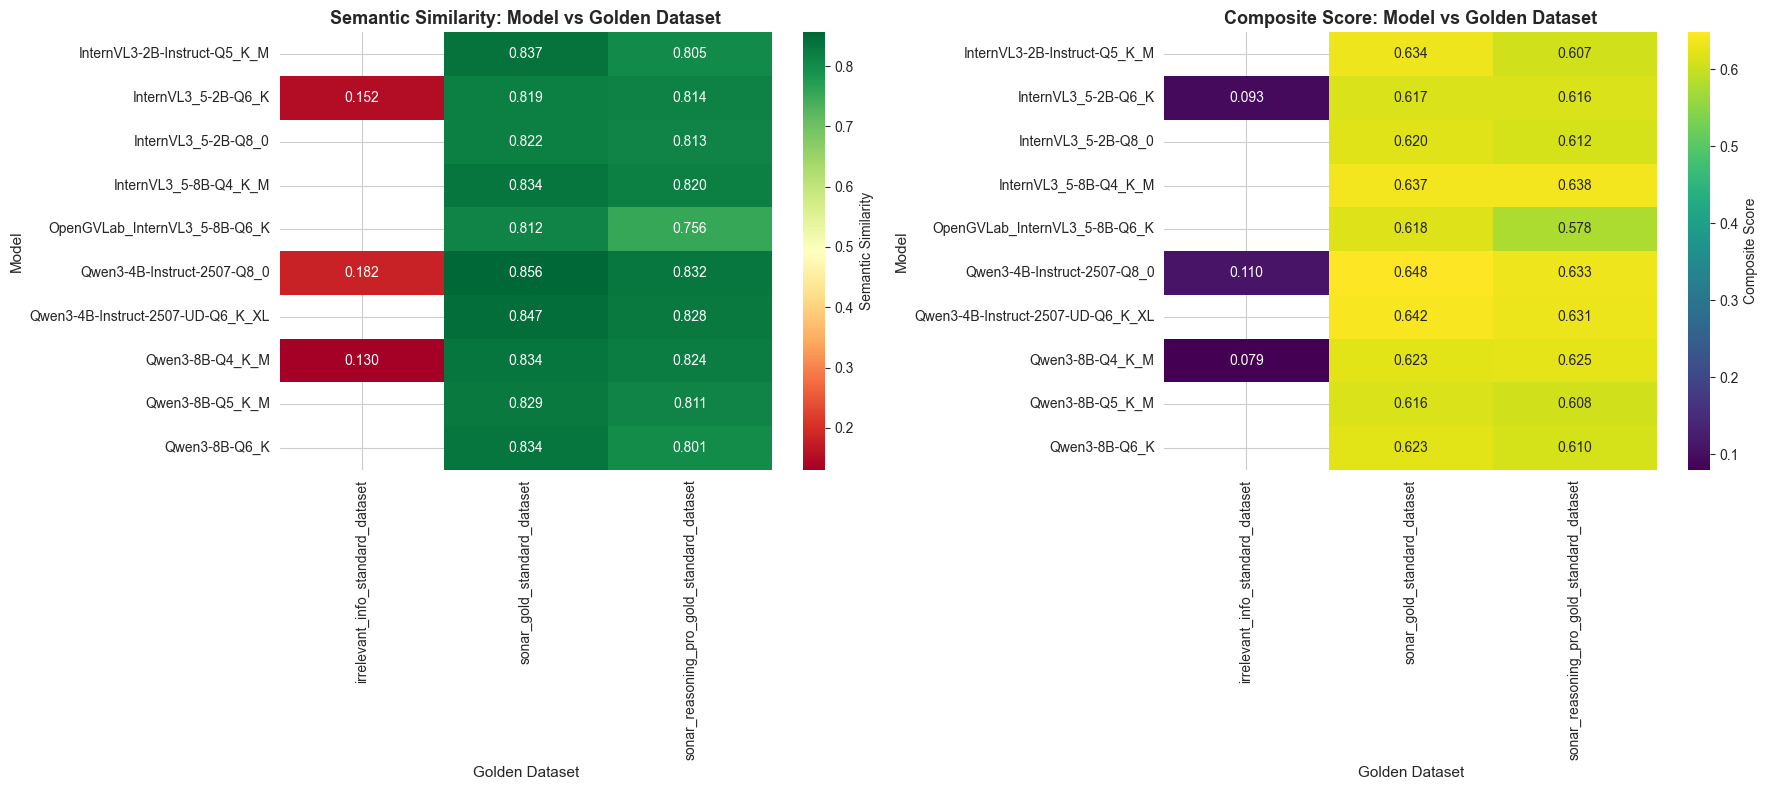

In [25]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Semantic Similarity Heatmap
    pivot_sem_dataset = df_latest_all.pivot_table(
        values='semantic_sim_mean',
        index='model',
        columns='dataset_name',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_sem_dataset, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[0], cbar_kws={'label': 'Semantic Similarity'})
    axes[0].set_title('Semantic Similarity: Model vs Golden Dataset', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Golden Dataset', fontsize=11)
    axes[0].set_ylabel('Model', fontsize=11)
    
    # Composite Score Heatmap
    pivot_comp_dataset = df_latest_all.pivot_table(
        values='composite_score',
        index='model',
        columns='dataset_name',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_comp_dataset, annot=True, fmt='.3f', cmap='viridis', 
                ax=axes[1], cbar_kws={'label': 'Composite Score'})
    axes[1].set_title('Composite Score: Model vs Golden Dataset', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Golden Dataset', fontsize=11)
    axes[1].set_ylabel('Model', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 11.5 Top-K Impact Across Datasets

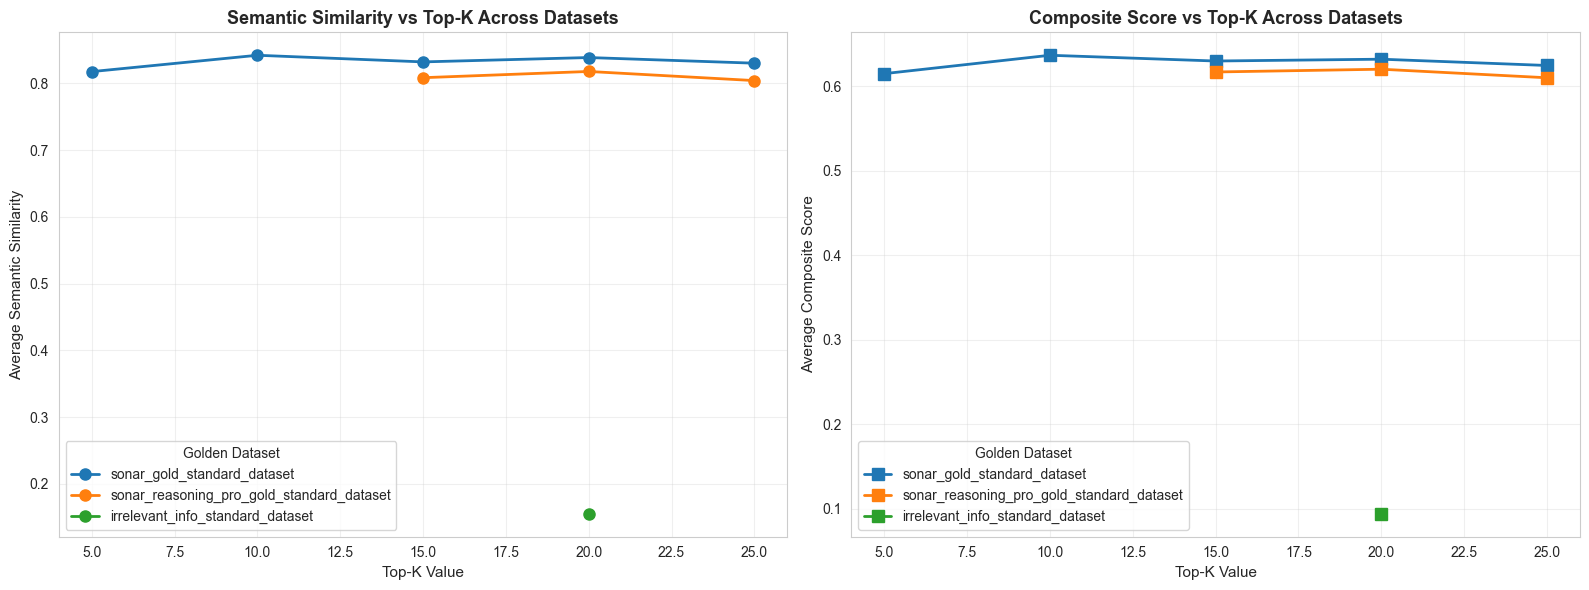

In [26]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Semantic Similarity by Top-K for each dataset
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_data = df_latest_all[df_latest_all['dataset_name'] == dataset]
        topk_avg = dataset_data.groupby('top_k')['semantic_sim_mean'].mean()
        axes[0].plot(topk_avg.index, topk_avg.values, marker='o', linewidth=2, 
                    label=dataset, markersize=8)
    
    axes[0].set_title('Semantic Similarity vs Top-K Across Datasets', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Top-K Value', fontsize=11)
    axes[0].set_ylabel('Average Semantic Similarity', fontsize=11)
    axes[0].legend(title='Golden Dataset', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Composite Score by Top-K for each dataset
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_data = df_latest_all[df_latest_all['dataset_name'] == dataset]
        topk_avg = dataset_data.groupby('top_k')['composite_score'].mean()
        axes[1].plot(topk_avg.index, topk_avg.values, marker='s', linewidth=2, 
                    label=dataset, markersize=8)
    
    axes[1].set_title('Composite Score vs Top-K Across Datasets', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Top-K Value', fontsize=11)
    axes[1].set_ylabel('Average Composite Score', fontsize=11)
    axes[1].legend(title='Golden Dataset', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 11.6 Variance Analysis: Dataset Consistency

VARIANCE ANALYSIS: Model Consistency Across Datasets

Lower std = More consistent across different golden datasets


semantic_sim_mean         bleu_mean          \
                                               mean     std      mean     std   
model                                                                           
InternVL3-2B-Instruct-Q5_K_M                 0.8248  0.0184    0.0835  0.0155   
InternVL3_5-2B-Q6_K                          0.7435  0.2222    0.0753  0.0313   
InternVL3_5-2B-Q8_0                          0.8185  0.0136    0.0859  0.0105   
InternVL3_5-8B-Q4_K_M                        0.8287  0.0215    0.1083  0.0201   
OpenGVLab_InternVL3_5-8B-Q6_K                0.7906  0.0475    0.0930  0.0192   
Qwen3-4B-Instruct-2507-Q8_0                  0.7733  0.2220    0.0909  0.0367   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            0.8399  0.0142    0.1016  0.0199   
Qwen3-8B-Q4_K_M                              0.7523  0.2334    0.0785  0.0346   
Qwen3-8B-Q5_K_M                              0.8222  0.0246    0.0740  0.0127   
Qwen3-8B-Q6_K                                0.8217  0.0195    0.0826  0.0140   

                                  composite_score          
                                             mean     std  
model                                                      
InternVL3-2B-Instruct-Q5_K_M               0.6240  0.0156  
InternVL3_5-2B-Q6_K                        0.5583  0.1750  
InternVL3_5-2B-Q8_0                        0.6171  0.0139  
InternVL3_5-8B-Q4_K_M                      0.6375  0.0184  
OpenGVLab_InternVL3_5-8B-Q6_K              0.6030  0.0321  
Qwen3-4B-Instruct-2507-Q8_0                0.5831  0.1776  
Qwen3-4B-Instruct-2507-UD-Q6_K_XL          0.6379  0.0104  
Qwen3-8B-Q4_K_M                            0.5631  0.1815  
Qwen3-8B-Q5_K_M                            0.6131  0.0159  
Qwen3-8B-Q6_K                              0.6183  0.0122

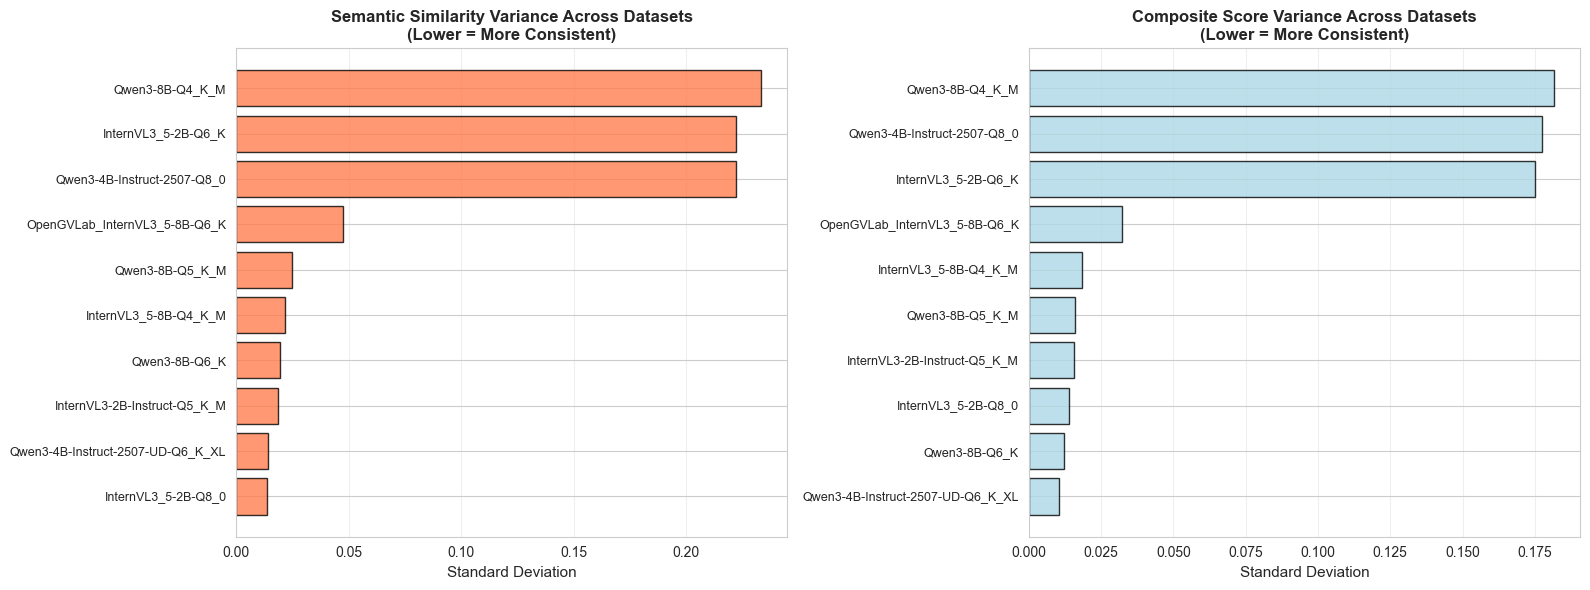

In [27]:
if len(unique_gold_datasets) > 1:
    # Calculate standard deviation across datasets for each model
    variance_analysis = df_latest.groupby('model').agg({
        'semantic_sim_mean': ['mean', 'std'],
        'bleu_mean': ['mean', 'std'],
        'composite_score': ['mean', 'std']
    }).round(4)
    
    print("="*80)
    print("VARIANCE ANALYSIS: Model Consistency Across Datasets")
    print("="*80)
    print("\nLower std = More consistent across different golden datasets")
    display(variance_analysis)
    
    # Visualize variance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    std_data = df_latest.groupby('model')['semantic_sim_mean'].std().sort_values()
    axes[0].barh(range(len(std_data)), std_data.values, color='coral', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(std_data)))
    axes[0].set_yticklabels(std_data.index, fontsize=9)
    axes[0].set_xlabel('Standard Deviation', fontsize=11)
    axes[0].set_title('Semantic Similarity Variance Across Datasets\n(Lower = More Consistent)', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    std_comp = df_latest.groupby('model')['composite_score'].std().sort_values()
    axes[1].barh(range(len(std_comp)), std_comp.values, color='lightblue', edgecolor='black', alpha=0.8)
    axes[1].set_yticks(range(len(std_comp)))
    axes[1].set_yticklabels(std_comp.index, fontsize=9)
    axes[1].set_xlabel('Standard Deviation', fontsize=11)
    axes[1].set_title('Composite Score Variance Across Datasets\n(Lower = More Consistent)', 
                     fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")